# **Store Sales Time Series Forecasting Using LSTM Using Data Corporación Favorita**

Berikut merupakan notebook utama penelitian tugas akhir yang saya kerjakan untuk seminar 1.

Pada tugas akhir ini saya melakukan analisis dan menerapkan statistika, pembelajaran mesin, dan pembelajaran mendalam untuk memprediksi penjualan dari dataset Corporación Favorita

sc : https://www.kaggle.com/competitions/store-sales-time-series-forecasting/code

---

Dengan struktur notebook sebagai berikut :
1. Data Loading
2. Preprocessing Data
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Development
6. Model Improvement
7. Saving The Best Model

## 1. Data Loading

In [1]:
# Install library jika belum ada
# !pip install xgboost scikit-learn tensorflow pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

import itertools
from tensorflow.keras.optimizers import Adam
import time
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Menetapkan Seed untuk Reproduksibilitas Ilmiah
SEED = 10122097
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed ditetapkan: {SEED}")

Random seed ditetapkan: 10122097


Saya juga memperbarui inisialisasi model di bawah untuk menggunakan seed tersebut.

In [2]:
# Memuat Data (Sesuaikan path dengan direktori Anda)
train = pd.read_csv("datasets/train.csv", parse_dates=['date'])
test = pd.read_csv("datasets/test.csv", parse_dates=['date'])
oil = pd.read_csv("datasets/oil.csv", parse_dates=['date'])
holidays = pd.read_csv("datasets/holidays_events.csv", parse_dates=['date'])
stores = pd.read_csv("datasets/stores.csv")
transactions = pd.read_csv("datasets/transactions.csv", parse_dates=['date'])

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [4]:
display(train.isnull().sum())
display(oil.isnull().sum())
display(holidays.isnull().sum())
display(stores.isnull().sum())
display(transactions.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

date           0
dcoilwtico    43
dtype: int64

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

date            0
store_nbr       0
transactions    0
dtype: int64

In [5]:
display(f'sum of train df duplicate: {train.duplicated().sum()}')
display(f'sum of oil df duplicate: {oil.duplicated().sum()}')
display(f'sum of holidays df duplicate: {holidays.duplicated().sum()}')
display(f'sum of stores df duplicate: {stores.duplicated().sum()}')
display(f'sum of transactions df duplicate: {transactions.duplicated().sum()}')

'sum of train df duplicate: 0'

'sum of oil df duplicate: 0'

'sum of holidays df duplicate: 0'

'sum of stores df duplicate: 0'

'sum of transactions df duplicate: 0'

In [6]:
# Berikut merupakan beberapa deskripsi mengenai data latih
train['store_nbr'] = train['store_nbr'].astype('object')

train.describe(include=['object'])

C:\Users\fikra\AppData\Local\Temp\ipykernel_14328\1408521482.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include=['object'])


,store_nbr,family
count,3000888,3000888
unique,54,33
top,1,AUTOMOTIVE
freq,55572,90936


In [7]:
# Melihat isi dari dataframes train
train

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [8]:
test

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [9]:
# Melihat data holidays
holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [10]:
# Melihat data dari stores data
stores

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [11]:
# Melihat data oil
oil

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


## 2. Exploratory Data Analysis

In [12]:
# Menampilkan semua jenis family yang unik di dataset
unique_families = train['family'].unique()
print(f"Total ada {len(unique_families)} jenis family:")
print(unique_families)

Total ada 33 jenis family:
<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
                    'PRODUCE', 'SCHOOL AND O

C:\Users\fikra\AppData\Local\Temp\ipykernel_14328\3972273597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales', y='family', data=family_sales, palette='viridis')


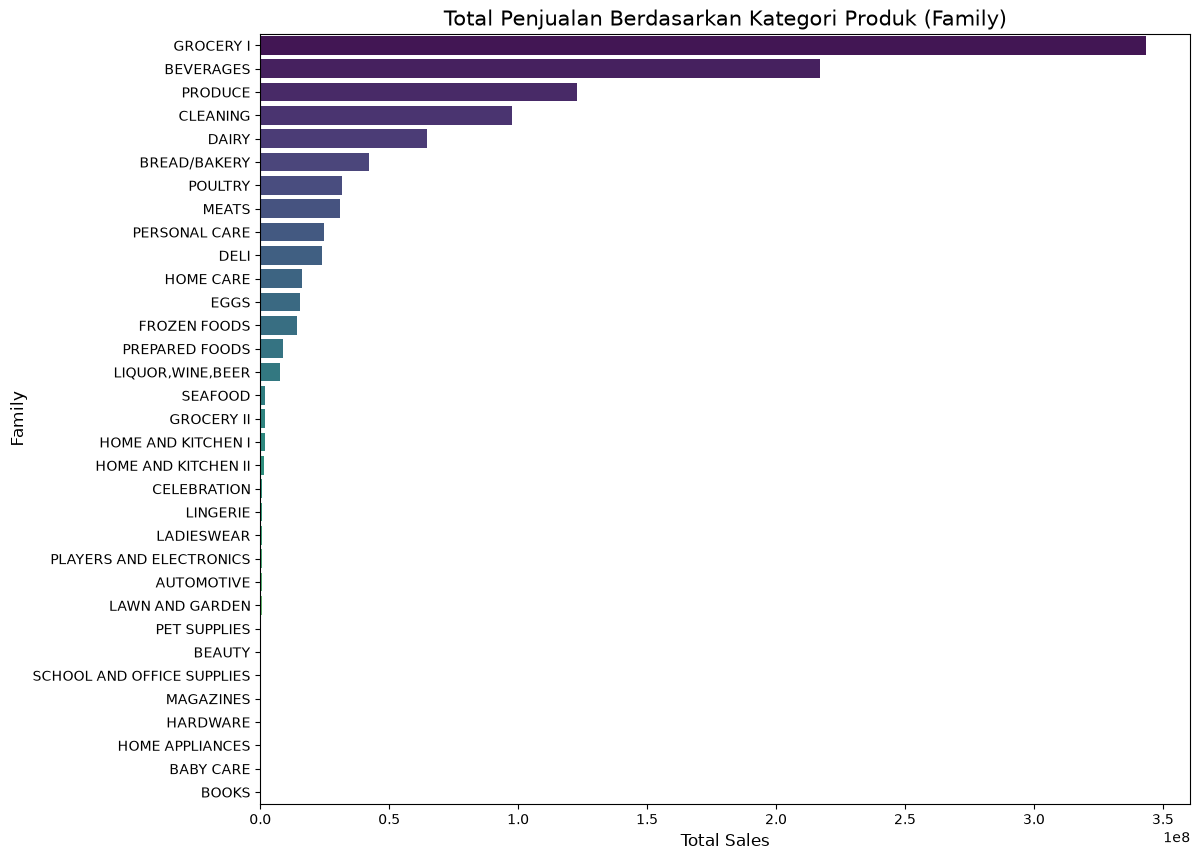

In [13]:
# Menghitung total penjualan per family
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()

# Membuat plot
plt.figure(figsize=(12, 10))
sns.barplot(x='sales', y='family', data=family_sales, palette='viridis')
plt.title('Total Penjualan Berdasarkan Kategori Produk (Family)', fontsize=15)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Family', fontsize=12)
plt.show()

In [14]:
# Selanjutnya akan dicek dari dataframe train bagaimana perilakunya
print('sales Mean: ', train.sales.mean())
train.sales.describe(
    percentiles=[0.1, 0.2, 0.25, 0.50, 0.7, 0.75, 0.9]
)

sales Mean:  357.77574911261877


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
10%      0.000000e+00
20%      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
70%      1.277660e+02
75%      1.958473e+02
90%      8.670000e+02
max      1.247170e+05
Name: sales, dtype: float64

Text(0.5, 1.0, 'Boxplot Semua Penjualan')

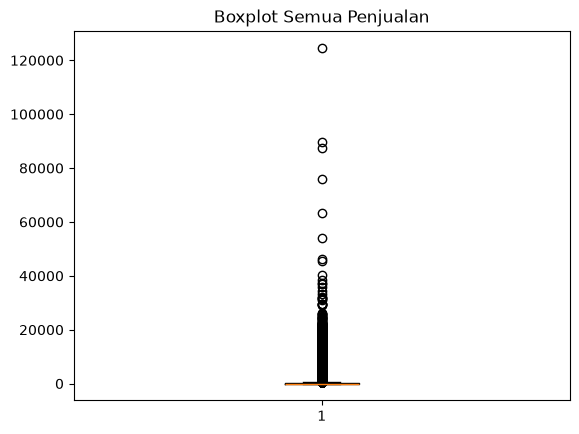

In [15]:
# Berikut merupakan boxplot dari semua stores dan families
plt.boxplot(train.sales)
plt.title('Boxplot Semua Penjualan')

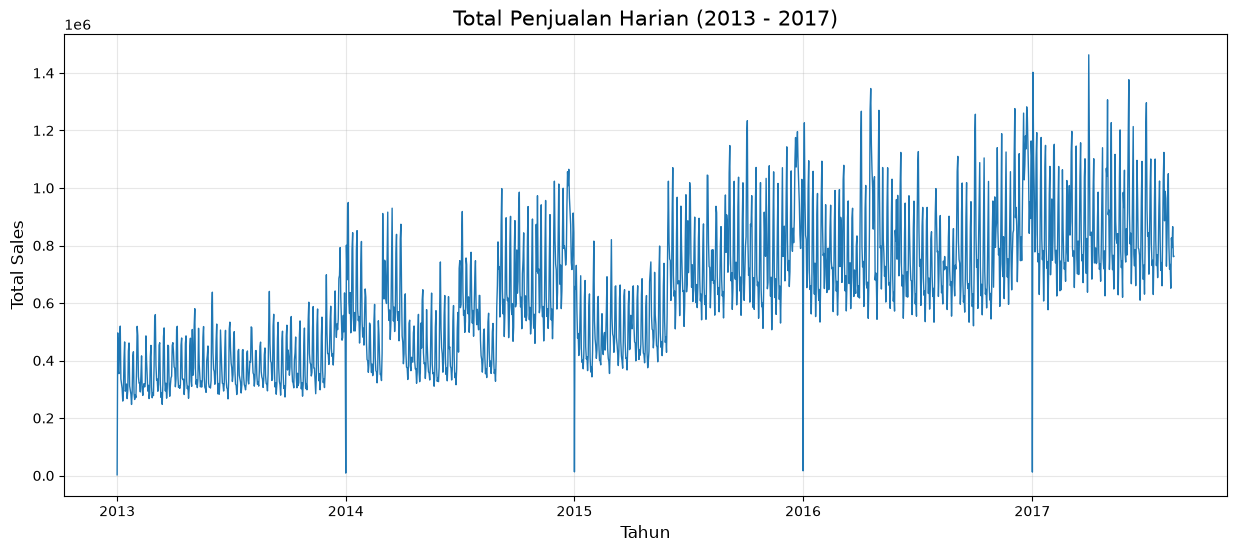

In [16]:
# Menghitung total penjualan harian di seluruh toko dan kategori
daily_sales = train.groupby('date')['sales'].sum()

# Membuat visualisasi tren waktu
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, color='tab:blue', linewidth=1)
plt.title('Total Penjualan Harian (2013 - 2017)', fontsize=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

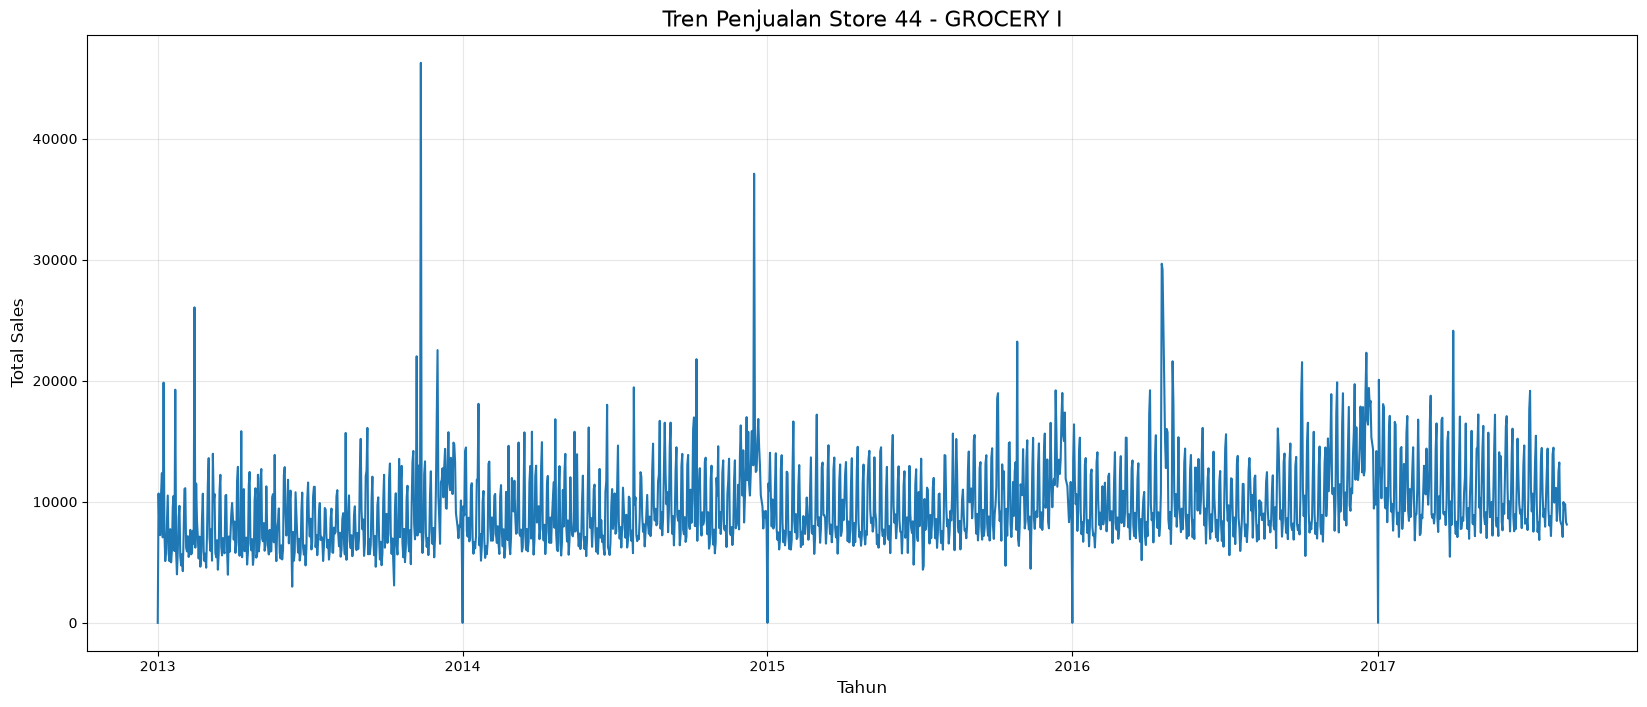

In [17]:
# Memplot penjualan Store 44 - BEVERAGES langsung menggunakan dataframe train
plt.figure(figsize=(20, 8))

# Filter data secara langsung dari dataframe train
data_plot_44_groceryi = train[(train['store_nbr'] == 44) & (train['family'] == 'GROCERY I')]

# Memplot hasil filter (menggunakan kolom date sebagai sumbu x)
plt.plot(data_plot_44_groceryi['date'], data_plot_44_groceryi['sales'], color='tab:blue')

plt.title('Tren Penjualan Store 44 - GROCERY I', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

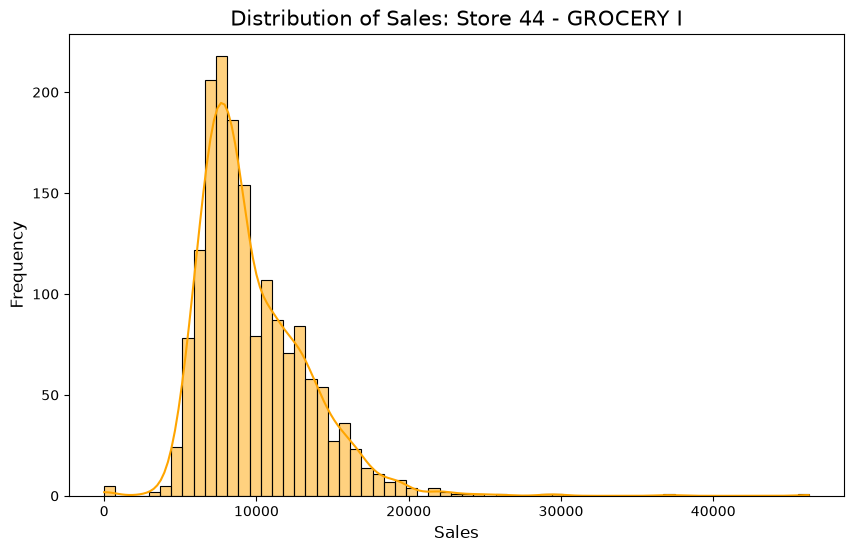

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data_plot_44_groceryi['sales'], kde=True, color='orange')
plt.title('Distribution of Sales: Store 44 - GROCERY I', fontsize=15)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

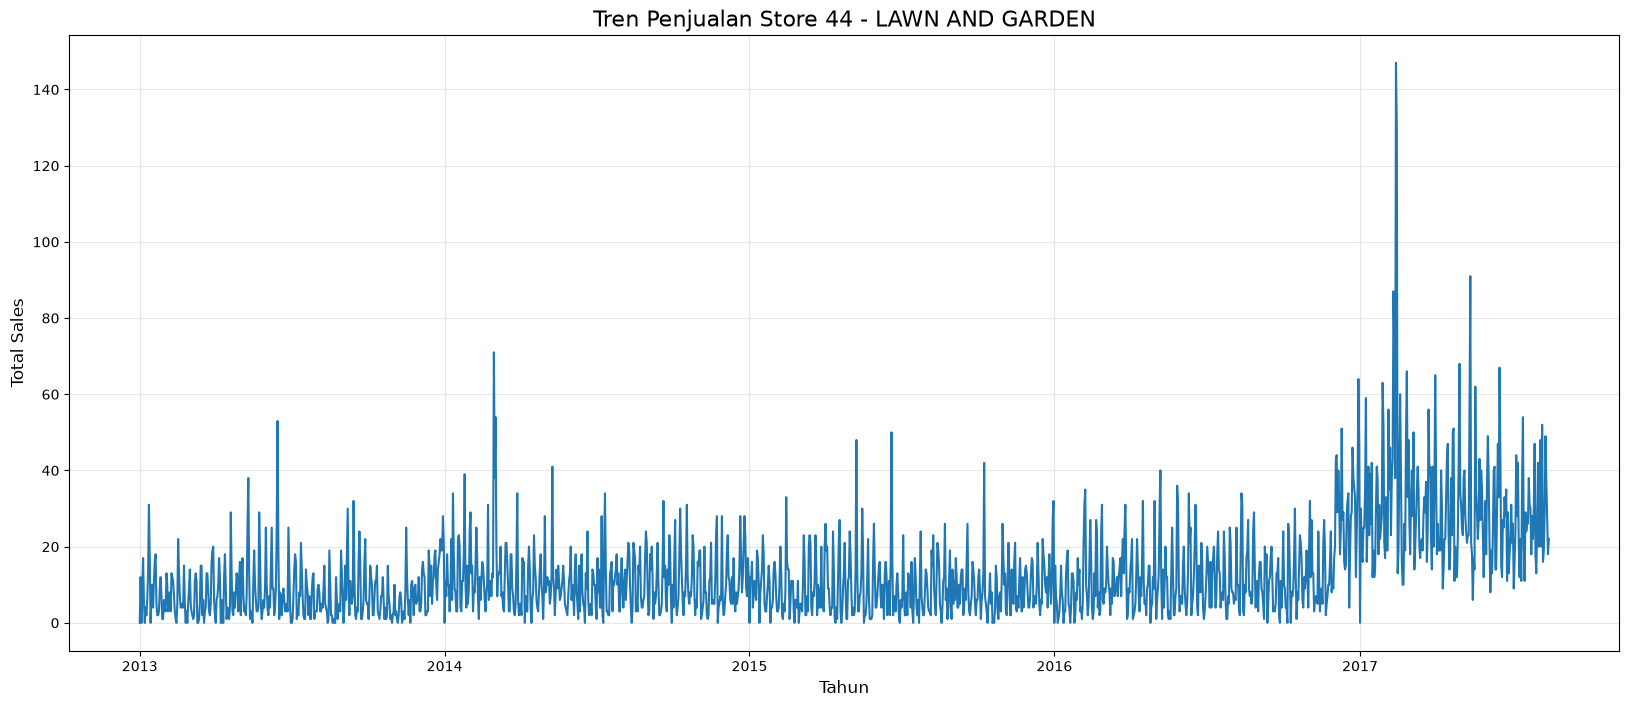

In [19]:
# Memplot penjualan Store 44 - BEVERAGES langsung menggunakan dataframe train
plt.figure(figsize=(20, 8))

# Filter data secara langsung dari dataframe train
data_plot_44_lawnandgarden = train[(train['store_nbr'] == 44) & (train['family'] == 'LAWN AND GARDEN')]

# Memplot hasil filter (menggunakan kolom date sebagai sumbu x)
plt.plot(data_plot_44_lawnandgarden['date'], data_plot_44_lawnandgarden['sales'], color='tab:blue')

plt.title('Tren Penjualan Store 44 - LAWN AND GARDEN', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

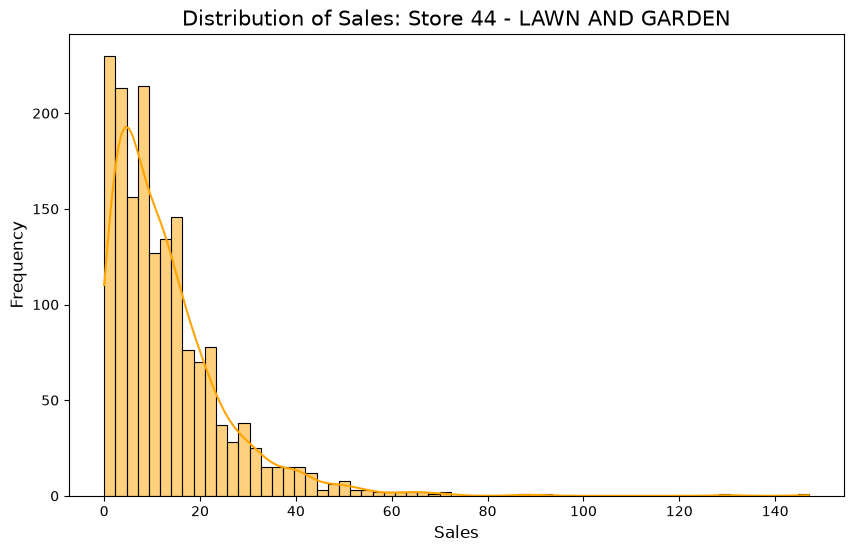

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data_plot_44_lawnandgarden['sales'], kde=True, color='orange')
plt.title('Distribution of Sales: Store 44 - LAWN AND GARDEN', fontsize=15)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

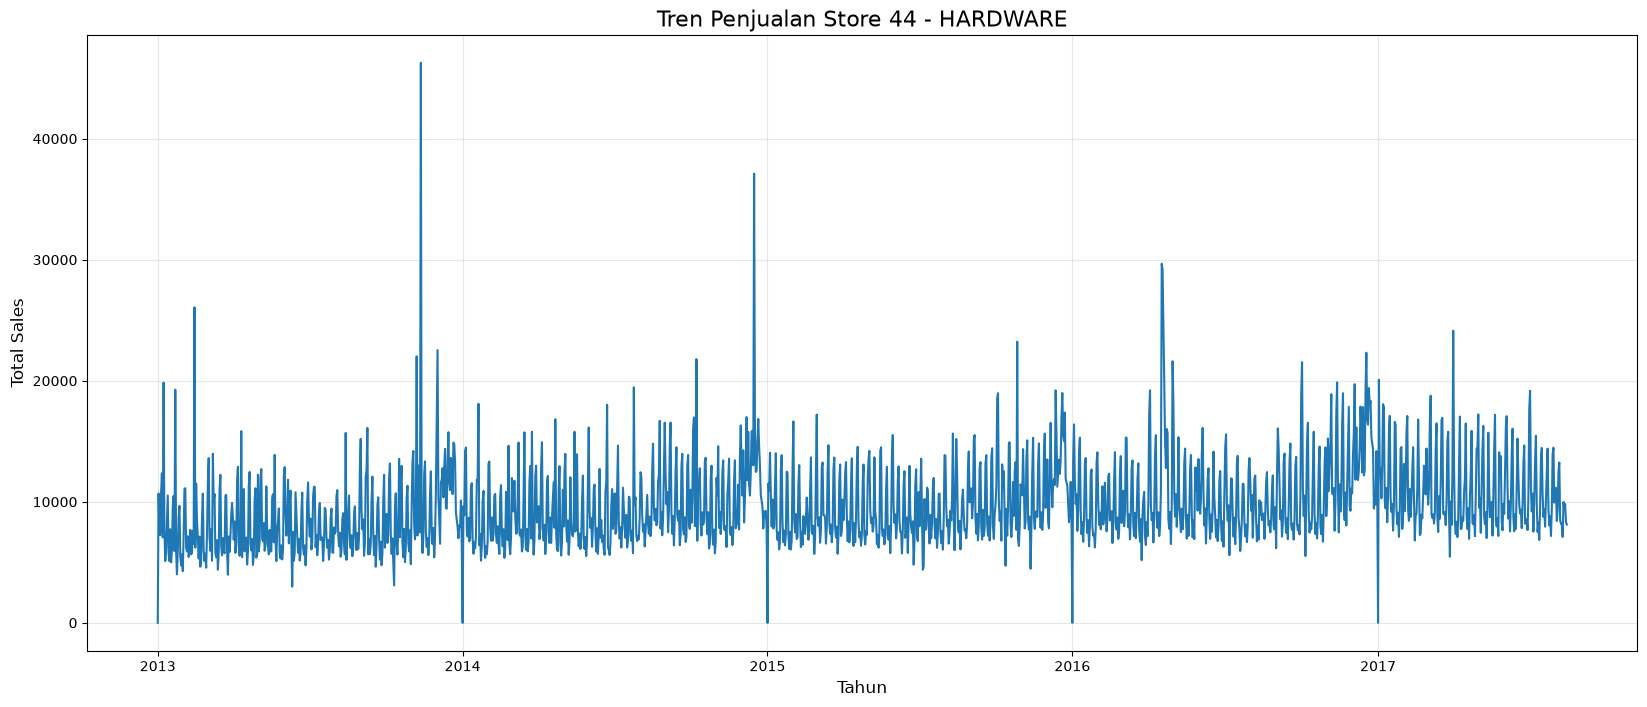

In [21]:
# Memplot penjualan Store 44 - HARDWARE langsung menggunakan dataframe train
plt.figure(figsize=(20, 8))

# Filter data secara langsung dari dataframe train
data_plot_44_hardware = train[(train['store_nbr'] == 44) & (train['family'] == 'HARDWARE')]

# Memplot hasil filter (menggunakan kolom date sebagai sumbu x)
plt.plot(data_plot_44_groceryi['date'], data_plot_44_groceryi['sales'], color='tab:blue')

plt.title('Tren Penjualan Store 44 - HARDWARE', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

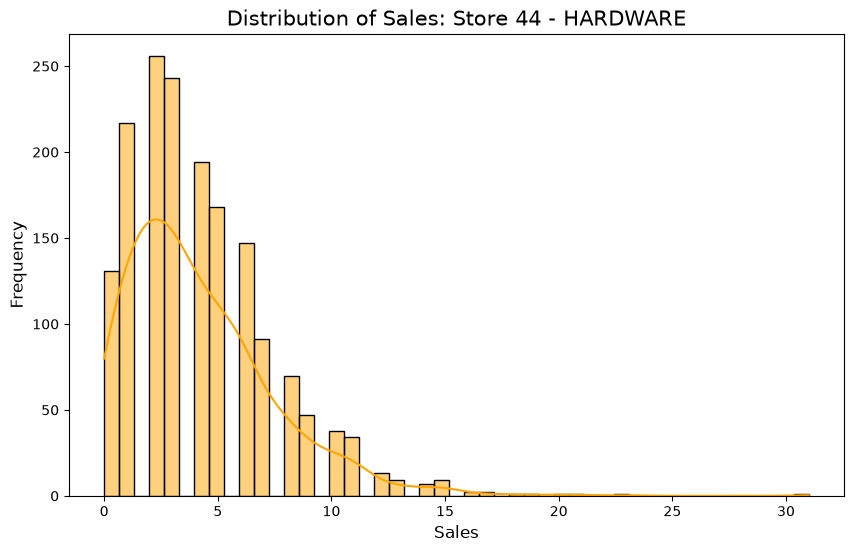

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(data_plot_44_hardware['sales'], kde=True, color='orange')
plt.title('Distribution of Sales: Store 44 - HARDWARE', fontsize=15)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

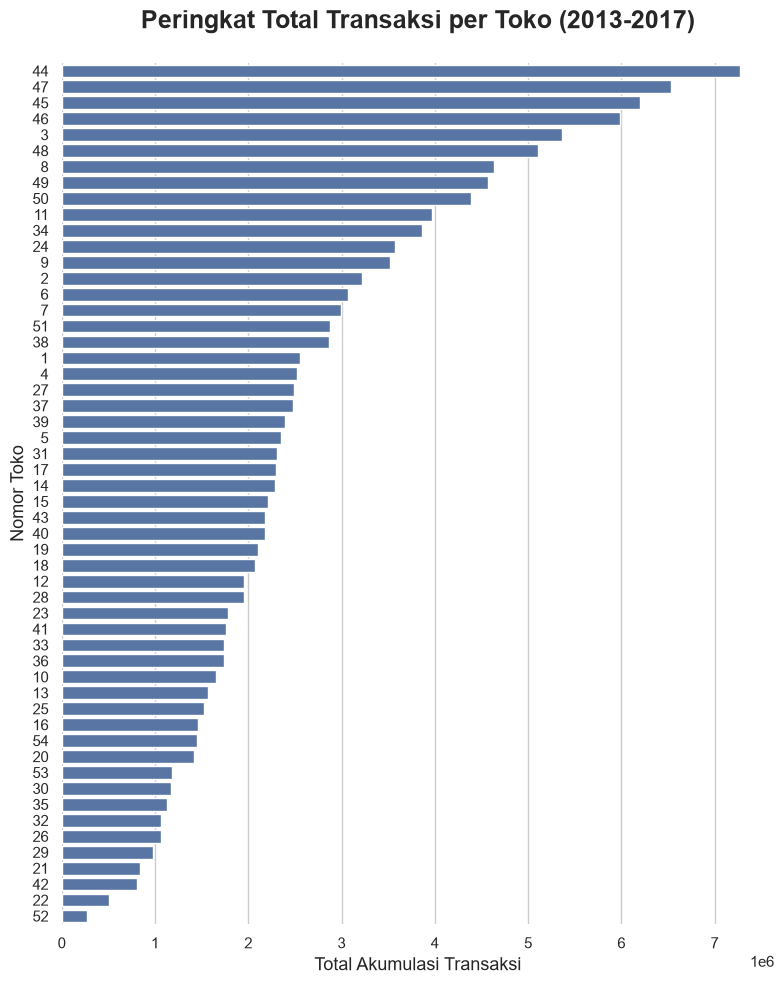

In [23]:
# Menghitung total transaksi dan mengurutkannya dari yang terbesar
store_transactions = transactions.groupby('store_nbr')['transactions'].sum().sort_values(ascending=False).reset_index()

# Set tema visual kembali ke whitegrid yang lebih bersih
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 10))

# Membuat plot dengan perbaikan pada parameter hue
plot = sns.barplot(
    x='transactions',
    y='store_nbr',
    data=store_transactions,
    orient='h',
    legend=False,
    order=store_transactions['store_nbr']
)

# Menambahkan detail teks dan estetika
plt.title('Peringkat Total Transaksi per Toko (2013-2017)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total Akumulasi Transaksi', fontsize=13)
plt.ylabel('Nomor Toko', fontsize=13)

# Menghilangkan border atas dan kanan
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

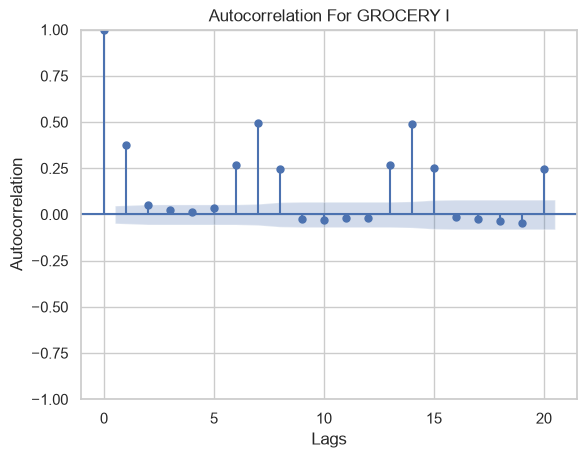

In [24]:
# Plot ACF untuk mengetahui adanya pola dalam data store 44 family grocery i
plot_acf(data_plot_44_groceryi['sales'], lags=20)
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation For GROCERY I")
plt.show()

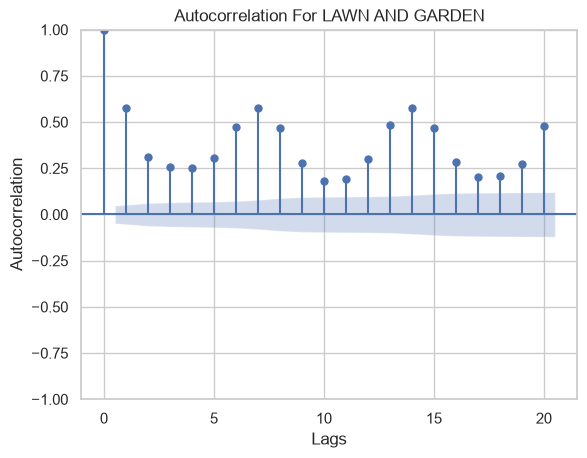

In [25]:
# Plot ACF untuk mengetahui adanya pola dalam data store 44 family lawn and garden
plot_acf(data_plot_44_lawnandgarden['sales'], lags=20)
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title('Autocorrelation For LAWN AND GARDEN')
plt.show()

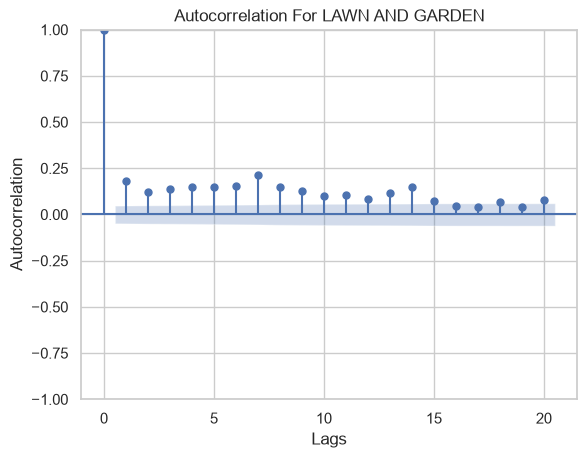

In [26]:
# Plot ACF untuk mengetahui adanya pola dalam data store 44 family lawn and garden
plot_acf(data_plot_44_hardware['sales'], lags=20)
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.title('Autocorrelation For LAWN AND GARDEN')
plt.show()

Memulai Analisis Sparsitas Khusus: GROCERY I & LAWN AND GARDEN (Store 44)...

--- HASIL METRIK SPARSITAS ---


,Family,ADI,CV2,Category,Zero_Sales_Ratio (%)
0,GROCERY I,1.003,0.132,Smooth (Stabil),0.297
1,LAWN AND GARDEN,1.037,0.853,Erratic (Sering tapi Bergejolak),3.563
2,HARDWARE,1.084,0.494,Erratic (Sering tapi Bergejolak),7.779


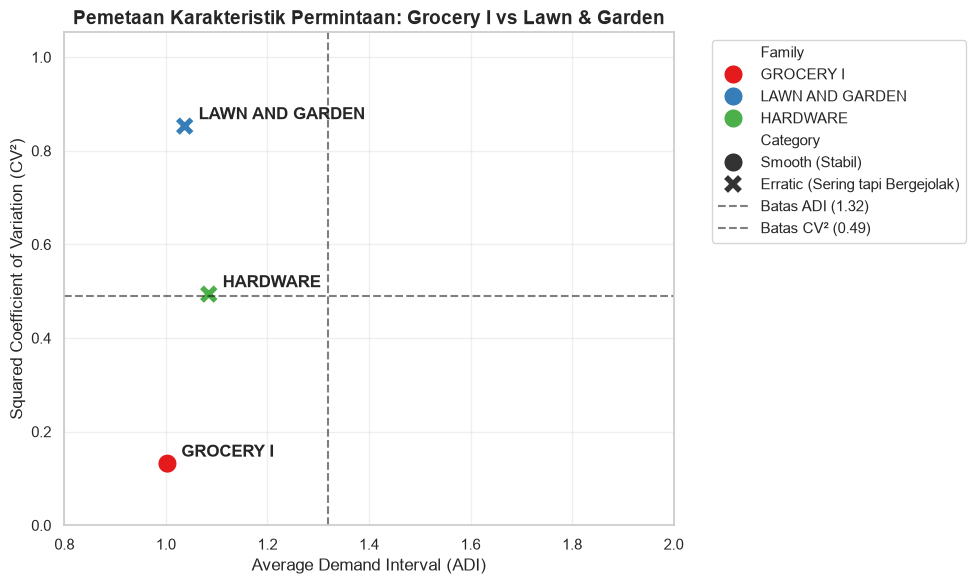

In [27]:
print("Memulai Analisis Sparsitas Khusus: GROCERY I & LAWN AND GARDEN (Store 44)...")

# 1. Tentukan Target Spesifik
target_store = 44
target_families = ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']

# Filter Data
df_filtered = train[(train['store_nbr'] == target_store) &
                    (train['family'].isin(target_families))].copy()

# Agregasi ke level harian per family
daily_sales = df_filtered.groupby(['family', 'date'])['sales'].sum().reset_index()

sparsity_metrics = []

# 2. Iterasi Perhitungan
for family in target_families:
    df_family = daily_sales[daily_sales['family'] == family]

    non_zero_sales = df_family[df_family['sales'] > 0]['sales']

    total_periods = len(df_family)
    non_zero_periods = len(non_zero_sales)

    if non_zero_periods == 0:
        continue

    # Perhitungan ADI dan CV^2
    adi = total_periods / non_zero_periods

    if non_zero_periods > 1:
        cv2 = (non_zero_sales.std() / non_zero_sales.mean()) ** 2
    else:
        cv2 = 0

    # Klasifikasi Syntetos-Boylan
    if adi < 1.32 and cv2 < 0.49:
        category = 'Smooth (Stabil)'
    elif adi >= 1.32 and cv2 < 0.49:
        category = 'Intermittent (Jarang tapi Stabil)'
    elif adi < 1.32 and cv2 >= 0.49:
        category = 'Erratic (Sering tapi Bergejolak)'
    else:
        category = 'Lumpy (Jarang & Bergejolak)'

    sparsity_metrics.append({
        'Family': family,
        'ADI': adi,
        'CV2': cv2,
        'Category': category,
        'Zero_Sales_Ratio (%)': ((total_periods - non_zero_periods) / total_periods) * 100
    })

# Tampilkan Tabel Hasil
df_sparsity = pd.DataFrame(sparsity_metrics)
print("\n--- HASIL METRIK SPARSITAS ---")
display(df_sparsity.round(3))

# =====================================================================
# 3. VISUALISASI KUADRAN
# =====================================================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='ADI', y='CV2',
    hue='Family', style='Category',
    data=df_sparsity,
    s=200, palette='Set1'
)

# Garis Batas Klasifikasi (Pastikan rentang sumbu mencakup garis ini)
plt.axvline(x=1.32, color='black', linestyle='--', alpha=0.5, label='Batas ADI (1.32)')
plt.axhline(y=0.49, color='black', linestyle='--', alpha=0.5, label='Batas CV² (0.49)')

# Memastikan grafik tidak terlalu "zoom-in" karena hanya ada 2 titik
plt.xlim(0.8, max(2.0, df_sparsity['ADI'].max() + 0.5))
plt.ylim(0.0, max(1.0, df_sparsity['CV2'].max() + 0.2))

# Anotasi Titik
for _, row in df_sparsity.iterrows():
    plt.annotate(
        row['Family'],
        (row['ADI'], row['CV2']),
        xytext=(10, 5), textcoords='offset points',
        fontsize=12, fontweight='bold'
    )

plt.title('Pemetaan Karakteristik Permintaan: Grocery I vs Lawn & Garden', fontsize=14, fontweight='bold')
plt.xlabel('Average Demand Interval (ADI)', fontsize=12)
plt.ylabel('Squared Coefficient of Variation (CV²)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing
---
Karena terdapat beberapa skenario yang harus dikerjakan maka disini akan dilakukan data preprocessing agar dapat dilakukan pelatihan.

In [28]:
# Fungsi metrik pembantu
def evaluate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    return mae, rmsle

# Fungsi pembentuk Tensor
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [29]:
# Menyiapkan skenario yang diperlukan dan juga time steps untuk seasonal naive
# Format: (store_nbr, 'family')
scenarios = [
    (44, 'GROCERY I'),
    (44, 'LAWN AND GARDEN'),
    (44, 'HARDWARE')
]
TIME_STEPS = 14

In [30]:
print("Memulai Feature Engineering dengan MinMaxScaler untuk semua skenario...")

# Dictionary untuk menyimpan tensor dari setiap skenario
processed_data = {}

for store, family in scenarios:
    # --- A. Data Filtering ---
    df_sub = train[(train['store_nbr'] == store) & (train['family'] == family)].copy()
    df_sub = df_sub.groupby('date')[['sales', 'onpromotion']].sum().reset_index()
    df_sub = df_sub.set_index('date').asfreq('D').fillna(0)

    oil_daily = oil.set_index('date').asfreq('D')
    oil_daily['dcoilwtico'] = oil_daily['dcoilwtico'].ffill().bfill()
    df_model = df_sub.join(oil_daily).rename(columns={'dcoilwtico': 'oil_price'})

    holidays_filtered = holidays[holidays['transferred'] == False].set_index('date')
    df_model['is_holiday'] = df_model.index.isin(holidays_filtered.index).astype(int)
    df_model = df_model.dropna()

    # --- B. Scaling (Menggunakan MinMaxScaler) ---
    feature_cols = ['onpromotion', 'oil_price', 'is_holiday']
    X_data = df_model[feature_cols]
    y_data = df_model['sales']

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data.values.reshape(-1, 1))

    # --- C. Pembentukan Tensor ---
    combined_scaled = np.hstack((y_scaled, X_scaled))
    X_seq, y_seq = [], []
    y_actual = y_data.values

    for i in range(len(combined_scaled) - TIME_STEPS):
        X_seq.append(combined_scaled[i : i + TIME_STEPS])
        y_seq.append(combined_scaled[i + TIME_STEPS, 0])

    X_seq, y_seq = np.array(X_seq), np.array(y_seq)
    y_actual_seq = y_actual[TIME_STEPS:]

    # --- D. Train/Test Split ---
    train_size = int(len(X_seq) * 0.8)

    # Simpan semua objek ke dalam dictionary agar siap dilatih
    processed_data[(store, family)] = {
        'X_train_3d': X_seq[:train_size],
        'X_test_3d': X_seq[train_size:],
        'y_train_scaled': y_seq[:train_size],
        'y_test_scaled': y_seq[train_size:],
        'y_test_actual': y_actual_seq[train_size:],
        'scaler_y': scaler_y
    }

print(f"✅ Feature Engineering (MinMaxScaler) selesai. {len(processed_data)} set tensor telah disimpan di memori.")

Memulai Feature Engineering dengan MinMaxScaler untuk semua skenario...
✅ Feature Engineering (MinMaxScaler) selesai. 3 set tensor telah disimpan di memori.


In [31]:
df_model.head()

,sales,onpromotion,oil_price,is_holiday
date,,,,
2013-01-01,0.0,0.0,93.14,1
2013-01-02,2.0,0.0,93.14,0
2013-01-03,1.0,0.0,92.97,0
2013-01-04,2.0,0.0,93.12,0
2013-01-05,9.0,0.0,93.12,1


In [32]:
# Melihat struktur dan panjang dari setiap tensor di processed_data
for (store, family), data in processed_data.items():
    print(f"=== Skenario: Store {store} - Family {family} ===")
    print(f"X_train_3d shape: {data['X_train_3d'].shape} (Length: {len(data['X_train_3d'])})")
    print(f"X_test_3d  shape: {data['X_test_3d'].shape}  (Length: {len(data['X_test_3d'])})")
    print(f"y_train_scaled shape: {data['y_train_scaled'].shape}")
    print(f"y_test_scaled  shape: {data['y_test_scaled'].shape}")
    print(f"y_test_actual  shape: {data['y_test_actual'].shape}")
    print("-" * 45)


=== Skenario: Store 44 - Family GROCERY I ===
X_train_3d shape: (1339, 14, 4) (Length: 1339)
X_test_3d  shape: (335, 14, 4)  (Length: 335)
y_train_scaled shape: (1339,)
y_test_scaled  shape: (335,)
y_test_actual  shape: (335,)
---------------------------------------------
=== Skenario: Store 44 - Family LAWN AND GARDEN ===
X_train_3d shape: (1339, 14, 4) (Length: 1339)
X_test_3d  shape: (335, 14, 4)  (Length: 335)
y_train_scaled shape: (1339,)
y_test_scaled  shape: (335,)
y_test_actual  shape: (335,)
---------------------------------------------
=== Skenario: Store 44 - Family HARDWARE ===
X_train_3d shape: (1339, 14, 4) (Length: 1339)
X_test_3d  shape: (335, 14, 4)  (Length: 335)
y_train_scaled shape: (1339,)
y_test_scaled  shape: (335,)
y_test_actual  shape: (335,)
---------------------------------------------


In [33]:
# Menampilkan 'head' (5 data pertama) dari struktur data di setiap skenario
for (store, family), data in processed_data.items():
    print(f"=== Head Data: Store {store} - Family {family} ===")

    print("\n1. X_train_3d (First sample, first 5 time steps):")
    # Menampilkan 5 time steps pertama dari sampel pertama
    print(data['X_train_3d'][0][:5])

    print("\n2. y_train_scaled (First 5 values):")
    print(data['y_train_scaled'][:5])

    print("\n3. y_test_actual (First 5 values):")
    print(data['y_test_actual'][:5])

    print("\n" + "="*50 + "\n")

=== Head Data: Store 44 - Family GROCERY I ===

1. X_train_3d (First sample, first 5 time steps):
[[0.         0.         0.79296459 1.        ]
 [0.23094379 0.         0.79296459 0.        ]
 [0.1586739  0.         0.79095108 0.        ]
 [0.15668561 0.         0.7927277  0.        ]
 [0.23122474 0.         0.7927277  1.        ]]

2. y_train_scaled (First 5 values):
[0.11013378 0.16721056 0.10801582 0.12967085 0.20807849]

3. y_test_actual (First 5 values):
[ 6912.  9515. 13314. 14816.  8043.]


=== Head Data: Store 44 - Family LAWN AND GARDEN ===

1. X_train_3d (First sample, first 5 time steps):
[[0.         0.         0.79296459 1.        ]
 [0.08163265 0.         0.79296459 0.        ]
 [0.         0.         0.79095108 0.        ]
 [0.05442177 0.         0.7927277  0.        ]
 [0.11564626 0.         0.7927277  1.        ]]

2. y_train_scaled (First 5 values):
[0.04761905 0.06802721 0.02721088 0.07482993 0.10884354]

3. y_test_actual (First 5 values):
[12. 17. 20. 12.  3.]


===

## 5. Model Development

### 5a. Pelatihan Model: Seasonal Naive, XGBoost, dan RNN
---
Pada bagian ini, kita akan melatih tiga model awal untuk melihat performa dasar dalam memprediksi penjualan pada skenario yang telah ditentukan.

In [36]:
# List untuk menampung rekapitulasi akhir
all_results = []

# --- Inisialisasi Early Stopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=0
)

for (store, family), data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"🚀 MELATIH MODEL BASELINE: STORE {store} | FAMILY {family}")
    print(f"{'='*60}")

    X_train_3d = data['X_train_3d']
    X_test_3d = data['X_test_3d']
    y_train_scaled = data['y_train_scaled']
    y_test_actual = data['y_test_actual']
    scaler_y = data['scaler_y']

    # --- Model 1: Seasonal Naive ---
    print("-> Mengevaluasi Seasonal Naive...")
    snaive_scaled_preds = X_test_3d[:, (TIME_STEPS - 7), 0]
    snaive_preds = scaler_y.inverse_transform(snaive_scaled_preds.reshape(-1, 1)).flatten()
    snaive_preds = np.maximum(snaive_preds, 0)
    mae_sn, rmsle_sn = evaluate_metrics(y_test_actual, snaive_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'Seasonal Naive', 'MAE': mae_sn, 'RMSLE': rmsle_sn})

    # --- Model 2: XGBoost ---
    print("-> Melatih XGBoost...")
    X_train_2d = X_train_3d.reshape(X_train_3d.shape[0], -1)
    X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)
    xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, n_jobs=-1)
    xgb_model.fit(X_train_2d, y_train_scaled, eval_set=[(X_train_2d, y_train_scaled)], verbose=False)
    xgb_preds_scaled = xgb_model.predict(X_test_2d)
    xgb_preds = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1)).flatten()
    xgb_preds = np.maximum(xgb_preds, 0)
    mae_xgb, rmsle_xgb = evaluate_metrics(y_test_actual, xgb_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'XGBoost', 'MAE': mae_xgb, 'RMSLE': rmsle_xgb})

    # --- Model 3: RNN ---
    print("-> Melatih Simple RNN...")
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    rnn_model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    rnn_model.compile(optimizer='adam', loss='mse')
    rnn_model.fit(X_train_3d, y_train_scaled, epochs=50, batch_size=32, validation_split=0.1, verbose=0, callbacks=[early_stop])
    rnn_preds_scaled = rnn_model.predict(X_test_3d, verbose=0)
    rnn_preds = scaler_y.inverse_transform(rnn_preds_scaled).flatten()
    rnn_preds = np.maximum(rnn_preds, 0)
    mae_rnn, rmsle_rnn = evaluate_metrics(y_test_actual, rnn_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'RNN', 'MAE': mae_rnn, 'RMSLE': rmsle_rnn})

# Tampilkan rekapitulasi sementara
display(pd.DataFrame(all_results).round(4))


🚀 MELATIH MODEL BASELINE: STORE 44 | FAMILY GROCERY I
-> Mengevaluasi Seasonal Naive...
-> Melatih XGBoost...
-> Melatih Simple RNN...


c:\Users\fikra\OneDrive\Desktop\sales-forecasting-lstm\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 MELATIH MODEL BASELINE: STORE 44 | FAMILY LAWN AND GARDEN
-> Mengevaluasi Seasonal Naive...
-> Melatih XGBoost...
-> Melatih Simple RNN...


c:\Users\fikra\OneDrive\Desktop\sales-forecasting-lstm\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 MELATIH MODEL BASELINE: STORE 44 | FAMILY HARDWARE
-> Mengevaluasi Seasonal Naive...
-> Melatih XGBoost...
-> Melatih Simple RNN...


c:\Users\fikra\OneDrive\Desktop\sales-forecasting-lstm\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Store,Family,Model,MAE,RMSLE
0,44,GROCERY I,Seasonal Naive,1948.3373,0.7925
1,44,GROCERY I,XGBoost,1731.9870,0.7443
2,44,GROCERY I,RNN,2080.4360,0.7675
3,44,LAWN AND GARDEN,Seasonal Naive,12.5433,0.7250
4,44,LAWN AND GARDEN,XGBoost,13.7108,0.7543
5,44,LAWN AND GARDEN,RNN,18.1087,1.4640
6,44,HARDWARE,Seasonal Naive,2.5313,0.7213
7,44,HARDWARE,XGBoost,2.2233,0.6269
8,44,HARDWARE,RNN,2.1477,0.6168


In [37]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,445 (52.52 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,964 (35.02 KB)

In [38]:
def plot_baseline_results(store, family, model_type, last_n=100):
    """
    Fungsi untuk memplot hasil prediksi baseline model dengan mengembalikan skala ke nilai asli.
    """
    if (store, family) not in processed_data:
        print(f"Data untuk {store} - {family} tidak ditemukan.")
        return

    data = processed_data[(store, family)]
    X_test_3d = data['X_test_3d']
    y_actual = data['y_test_actual']
    scaler_y = data['scaler_y']

    if model_type == 'Seasonal Naive':
        preds_scaled = X_test_3d[:, (TIME_STEPS - 7), 0]
        preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

    elif model_type == 'XGBoost':
        X_train_2d = data['X_train_3d'].reshape(data['X_train_3d'].shape[0], -1)
        X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)
        xgb_m = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED)
        xgb_m.fit(X_train_2d, data['y_train_scaled'])
        preds_scaled = xgb_m.predict(X_test_2d)
        preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

    elif model_type == 'RNN':
        rnn_m = Sequential([
            Input(shape=(X_test_3d.shape[1], X_test_3d.shape[2])),
            SimpleRNN(64, return_sequences=True),
            Dropout(0.2),
            SimpleRNN(32),
            Dense(1)
        ])
        rnn_m.compile(optimizer='adam', loss='mse')
        rnn_m.fit(data['X_train_3d'], data['y_train_scaled'], epochs=10, batch_size=32, verbose=0)
        preds_scaled = rnn_m.predict(X_test_3d, verbose=0)
        preds = scaler_y.inverse_transform(preds_scaled).flatten()

    preds = np.maximum(preds, 0)
    mae, rmsle = evaluate_metrics(y_actual, preds)

    plt.figure(figsize=(15, 5))
    plt.plot(y_actual[-last_n:], label='Actual Sales', color='black', alpha=0.6, linewidth=2)
    plt.plot(preds[-last_n:], label=f'{model_type} Prediction', linestyle='--')

    plt.title(f"{model_type} Prediction vs Actual (Original Scale): Store {store} - {family}\nMAE: {mae:.2f} | RMSLE: {rmsle:.4f}")
    plt.xlabel(f"Time Steps (Last {last_n} days)")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Contoh Penggunaan Fungsi Summary Baseline
Kita dapat memanggil fungsi ini untuk melihat detail per model seperti pada model LSTM sebelumnya.

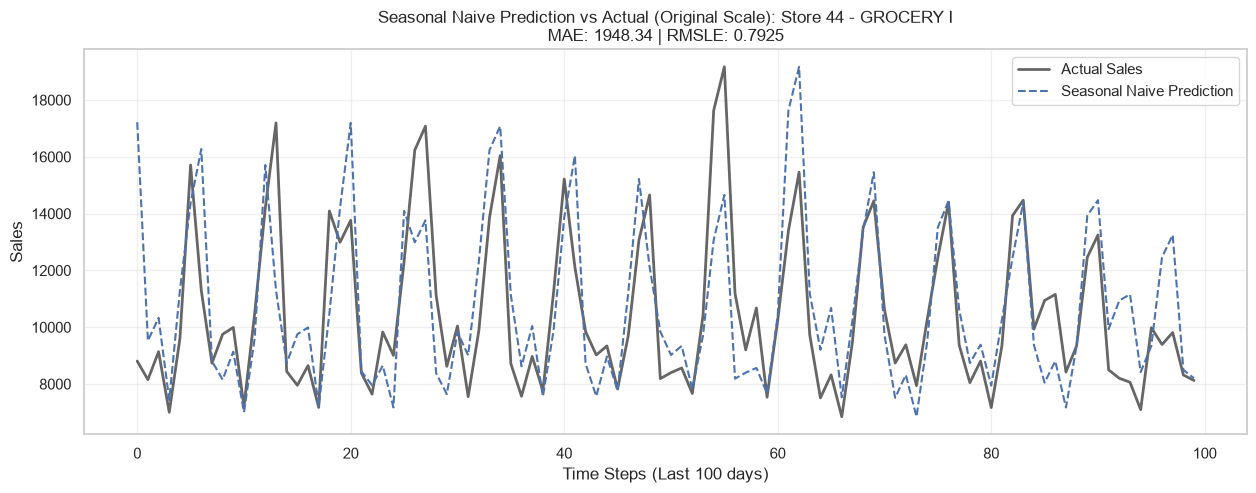

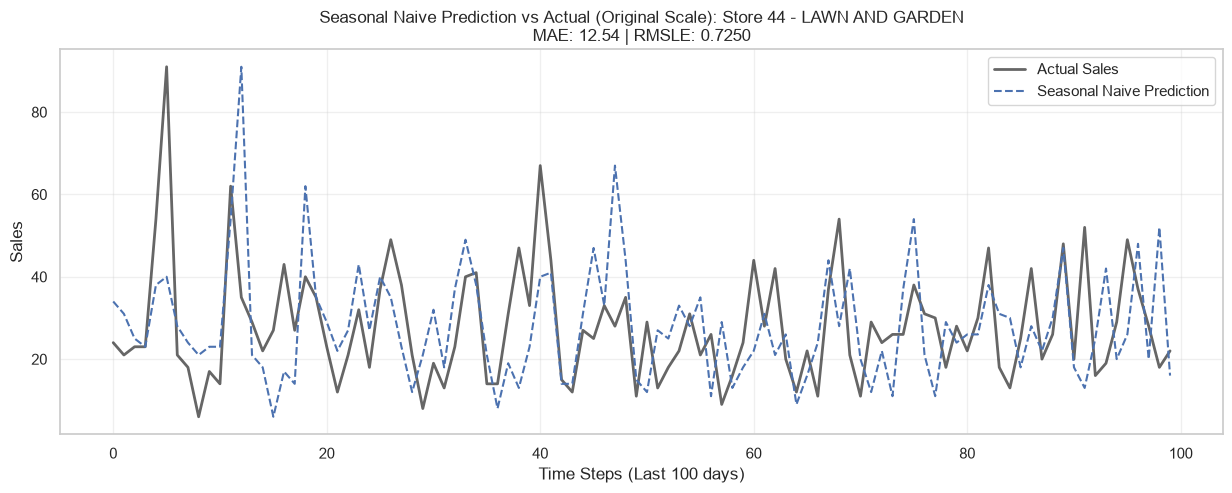

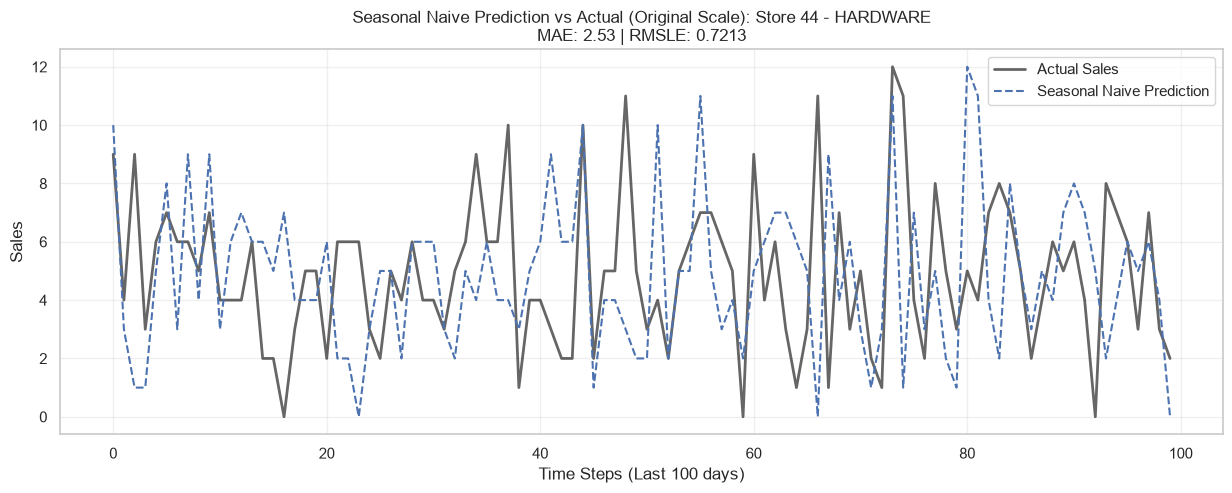

In [39]:
# Contoh menampilkan summary untuk Grocery I di Store 44 menggunakan model Seasonal Naive
for fam in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    plot_baseline_results(44, fam, 'Seasonal Naive', last_n=100)

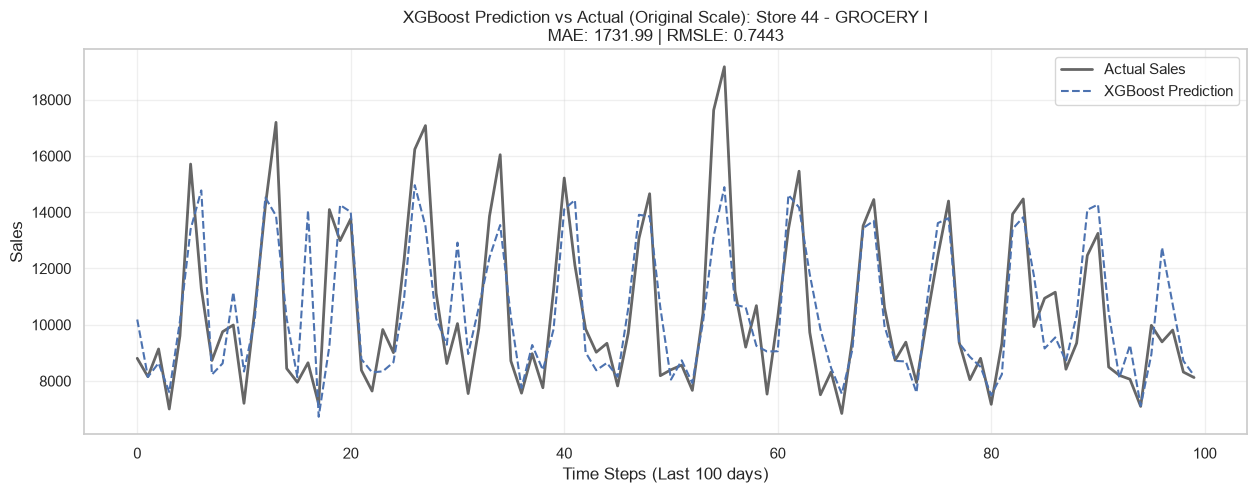

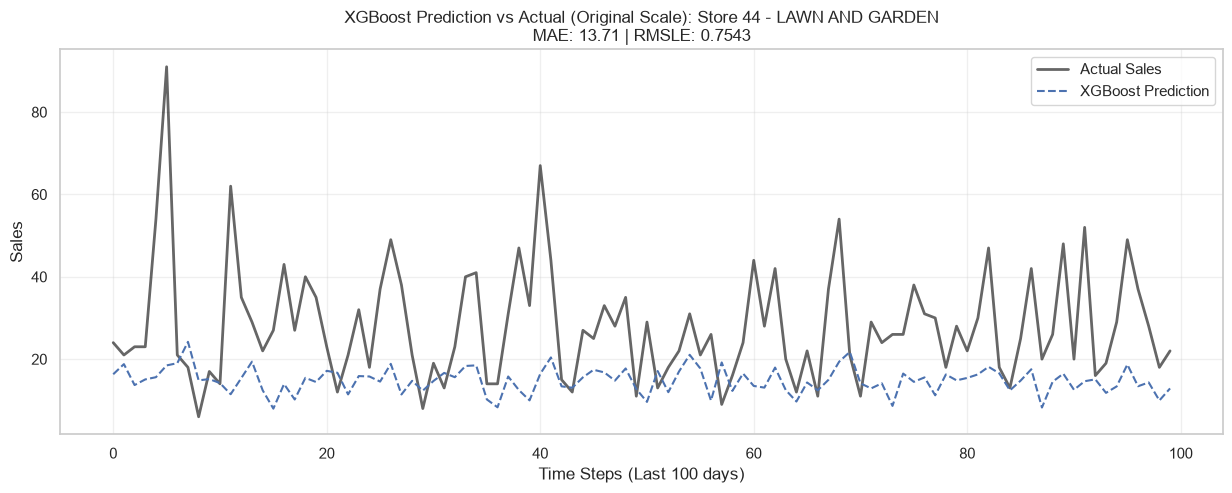

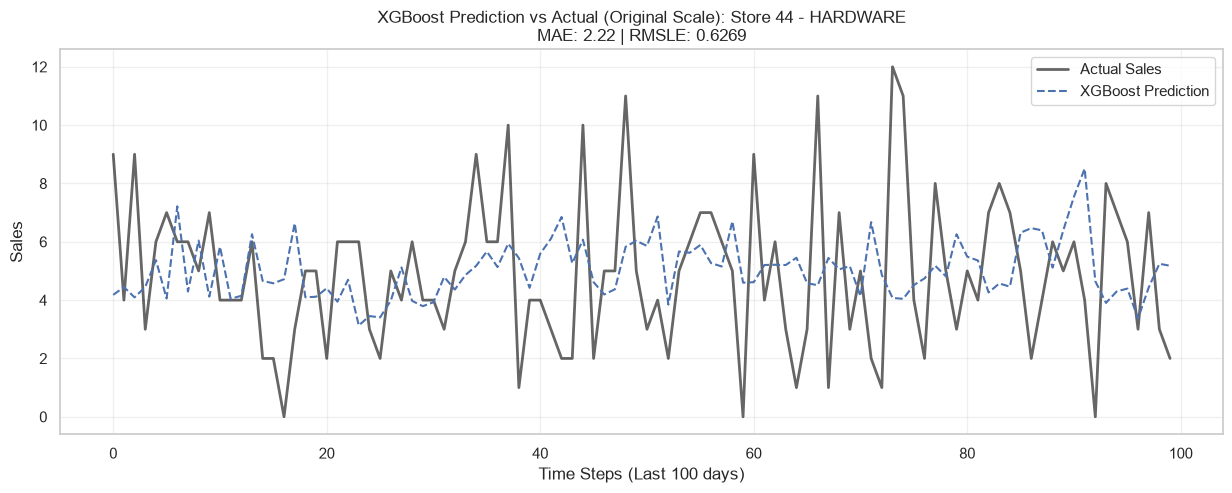

In [40]:
# Contoh menampilkan summary untuk Grocery I di Store 44 menggunakan model XGBoost
for fam in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    plot_baseline_results(44, fam, 'XGBoost', last_n=100)

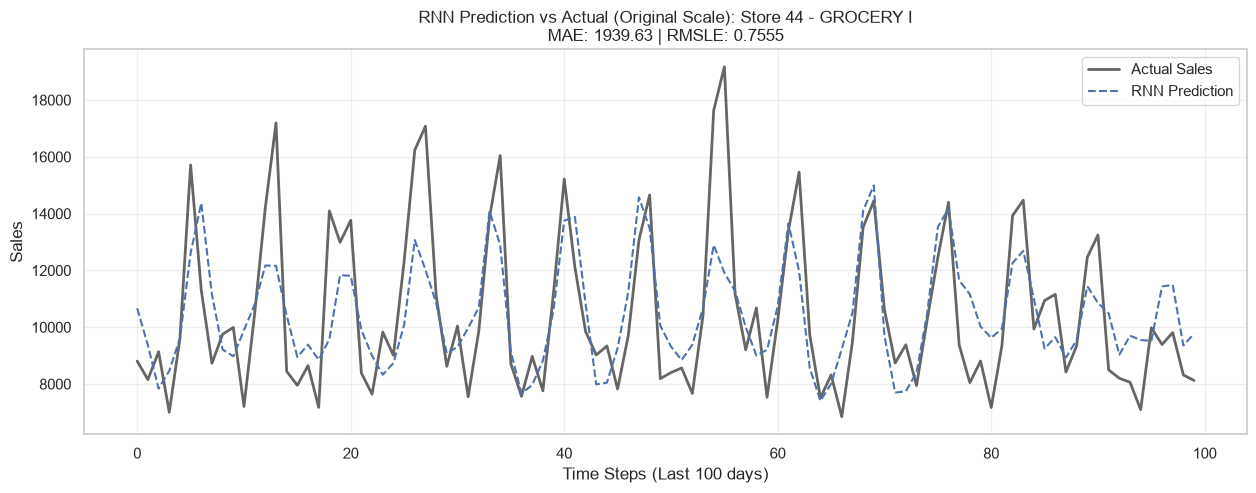

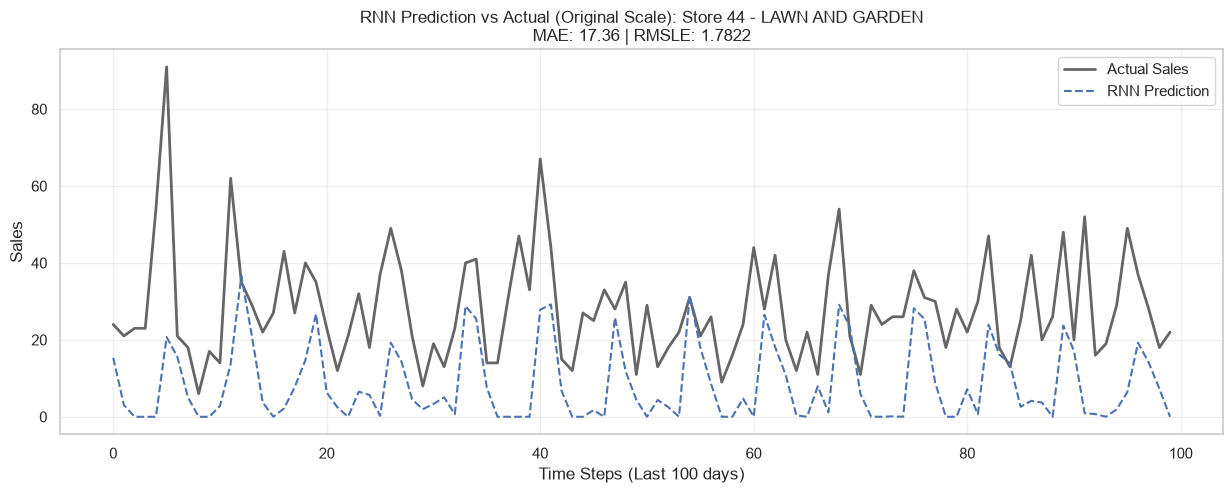

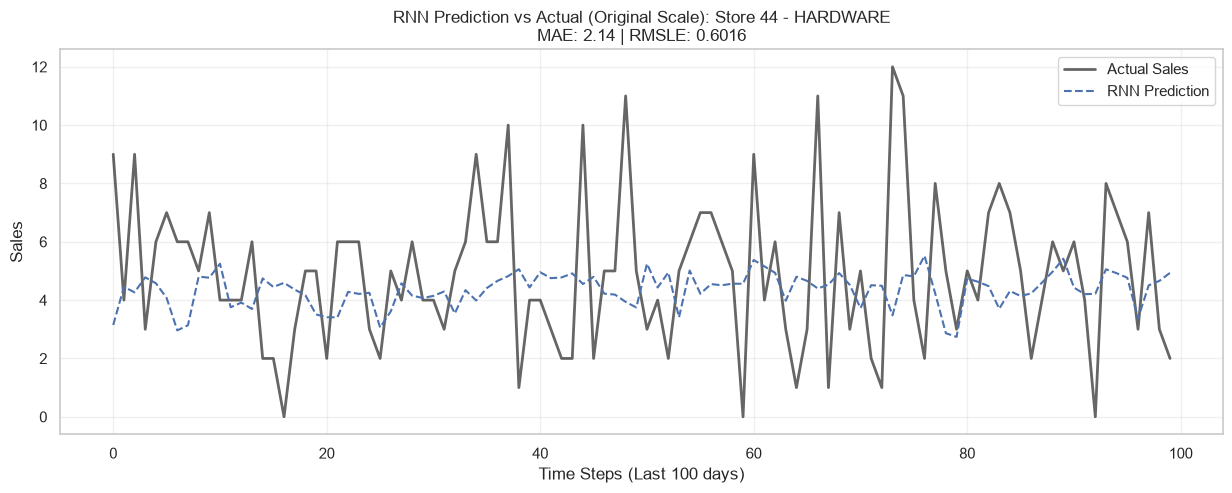

In [41]:
# Contoh menampilkan summary untuk Grocery I di Store 44 menggunakan model XGBoost
for fam in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    plot_baseline_results(44, fam, 'RNN', last_n=100)

## 6. Pengembangan Model LSTM & Hyperparameter Tuning
---
Pada bagian ini, kita akan fokus mendalam pada model LSTM. Kita akan melakukan pencarian parameter terbaik (hyperparameter tuning) untuk mendapatkan performa prediksi yang lebih optimal dibandingkan model-model baseline sebelumnya.

Parameter yang di-tuning:
- **num_cells** (jumlah unit LSTM): `[10, 30, 50]`
- **dropout_rate**: `[0, 0.1, 0.2]`
- **learning_rate**: `[1e-4, 1e-2, 1e-3]`

In [42]:
# =============================================================
# Fungsi-Fungsi Pembantu untuk LSTM Tuning, Evaluasi, dan Plot
# =============================================================

def build_lstm_model(num_cells, dropout_rate, learning_rate, input_shape):
    """
    Membangun dan mengompilasi model LSTM dengan hyperparameter yang diberikan.
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    
    model = Sequential([
        Input(shape=input_shape),
        LSTM(num_cells, dropout=dropout_rate),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model


def plot_loss_history(history, title='Loss Function History'):
    """
    Memplot grafik loss (train vs validation) dari history pelatihan.
    """
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_and_print(y_true, y_pred, label='Model'):
    """
    Mengevaluasi prediksi menggunakan MAE dan RMSLE, lalu mencetak hasilnya.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    print(f"  [{label}] MAE  = {mae:.4f}")
    print(f"  [{label}] RMSLE = {rmsle:.6f}")
    return mae, rmsle


def plot_actual_vs_predicted(y_actual, y_pred, title='Actual vs Predicted', last_n=150):
    """
    Memplot data asli vs prediksi LSTM (skala asli).
    """
    plt.figure(figsize=(15, 6))
    plt.plot(y_actual[-last_n:], label='Data Asli (Actual)', color='black', linewidth=2, alpha=0.7)
    plt.plot(y_pred[-last_n:], label='Prediksi LSTM', color='red', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel(f'Time Steps (Last {last_n} days)', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Fungsi-fungsi pembantu berhasil didefinisikan.')

Fungsi-fungsi pembantu berhasil didefinisikan.


In [43]:
# =============================================================
# Hyperparameter Tuning LSTM untuk Semua Skenario
# =============================================================

# Definisi ruang pencarian hyperparameter
param_num_cells = [10, 30, 50] # [32, 64, 128]
param_dropout_rate = [0, 0.1, 0.2]
param_learning_rate = [1e-4, 1e-2, 1e-3]

# Dictionary untuk menyimpan semua hasil tuning per skenario
all_tuning_results = {}

# Early stopping callback
early_stop_tuning = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

for (store, family), data in processed_data.items():
    print(f"\n{'='*70}")
    print(f"  TUNING LSTM: STORE {store} | FAMILY {family}")
    print(f"{'='*70}")

    X_train_full = data['X_train_3d']
    y_train_full = data['y_train_scaled']

    # Split manual untuk validation (80% train, 20% val)
    split_idx = int(len(X_train_full) * 0.8)
    X_train_split = X_train_full[:split_idx]
    X_val_split = X_train_full[split_idx:]
    y_train_split = y_train_full[:split_idx]
    y_val_split = y_train_full[split_idx:]

    results = {}
    total_combos = len(param_num_cells) * len(param_dropout_rate) * len(param_learning_rate)
    combo_count = 0

    for num_cells in param_num_cells:
        for dropout_rate in param_dropout_rate:
            for lr in param_learning_rate:
                combo_count += 1
                print(f'  [{combo_count}/{total_combos}] cells={num_cells}, dropout={dropout_rate}, lr={lr}', end=' ')

                model = build_lstm_model(
                    num_cells=num_cells,
                    dropout_rate=dropout_rate,
                    learning_rate=lr,
                    input_shape=(X_train_full.shape[1], X_train_full.shape[2])
                )

                history = model.fit(
                    X_train_split, y_train_split,
                    epochs=200,
                    batch_size=128,
                    validation_data=(X_val_split, y_val_split),
                    callbacks=[early_stop_tuning],
                    verbose=0,
                    shuffle=True
                )

                # Ambil loss terbaik (karena restore_best_weights=True)
                best_val_loss = min(history.history['val_loss'])
                best_epoch = history.history['val_loss'].index(best_val_loss) + 1
                train_loss_at_best = history.history['loss'][best_epoch - 1]

                results[(num_cells, dropout_rate, lr)] = {
                    'train_mse': train_loss_at_best,
                    'val_mse': best_val_loss,
                    'best_epoch': best_epoch,
                    'model': model,
                    'history': history
                }

                print(f'-> val_mse={best_val_loss:.6f} (epoch {best_epoch})')

    # Tentukan model terbaik berdasarkan val_mse
    best_key = min(results, key=lambda k: results[k]['val_mse'])
    best_result = results[best_key]

    print(f"\n  >> Parameter Terbaik: cells={best_key[0]}, dropout={best_key[1]}, lr={best_key[2]}")
    print(f"  >> Best Val MSE: {best_result['val_mse']:.6f} pada epoch {best_result['best_epoch']}")

    all_tuning_results[(store, family)] = {
        'best_params': best_key,
        'all_results': results,
        'best_model': best_result['model'],
        'best_history': best_result['history']
    }

print(f"\nTuning selesai untuk semua {len(processed_data)} skenario.")


  TUNING LSTM: STORE 44 | FAMILY GROCERY I
  [1/27] cells=10, dropout=0, lr=0.0001 -> val_mse=0.007333 (epoch 27)
  [2/27] cells=10, dropout=0, lr=0.01 -> val_mse=0.007254 (epoch 2)
  [3/27] cells=10, dropout=0, lr=0.001 -> val_mse=0.012996 (epoch 1)
  [4/27] cells=10, dropout=0.1, lr=0.0001 -> val_mse=0.008378 (epoch 35)
  [5/27] cells=10, dropout=0.1, lr=0.01 -> val_mse=0.004594 (epoch 53)
  [6/27] cells=10, dropout=0.1, lr=0.001 -> val_mse=0.008516 (epoch 1)
  [7/27] cells=10, dropout=0.2, lr=0.0001 -> val_mse=0.006042 (epoch 183)
  [8/27] cells=10, dropout=0.2, lr=0.01 -> val_mse=0.004481 (epoch 46)
  [9/27] cells=10, dropout=0.2, lr=0.001 -> val_mse=0.006256 (epoch 6)
  [10/27] cells=30, dropout=0, lr=0.0001 -> val_mse=0.006372 (epoch 30)
  [11/27] cells=30, dropout=0, lr=0.01 -> val_mse=0.005727 (epoch 1)
  [12/27] cells=30, dropout=0, lr=0.001 -> val_mse=0.005511 (epoch 14)
  [13/27] cells=30, dropout=0.1, lr=0.0001 -> val_mse=0.006729 (epoch 34)
  [14/27] cells=30, dropout=0.1

In [44]:
# =============================================================
# Tabel Rekapitulasi Hasil Tuning untuk Semua Skenario
# =============================================================

tuning_summary = []

for (store, family), res in all_tuning_results.items():
    for (cells, dr, lr), vals in res['all_results'].items():
        tuning_summary.append({
            'Store': store,
            'Family': family,
            'Num Cells': cells,
            'Dropout': dr,
            'Learning Rate': lr,
            'Train MSE': vals['train_mse'],
            'Val MSE': vals['val_mse'],
            'Best Epoch': vals['best_epoch']
        })

df_tuning = pd.DataFrame(tuning_summary)
df_tuning = df_tuning.sort_values(by=['Family', 'Val MSE']).reset_index(drop=True)

print('=== Rekapitulasi Hasil Tuning LSTM ===')
display(df_tuning.round(6))

# Tampilkan parameter terbaik per skenario
print('\n=== Parameter Terbaik per Skenario ===')
for (store, family), res in all_tuning_results.items():
    bp = res['best_params']
    print(f"  Store {store} - {family}: cells={bp[0]}, dropout={bp[1]}, lr={bp[2]}")

=== Rekapitulasi Hasil Tuning LSTM ===


,Store,Family,Num Cells,Dropout,Learning Rate,Train MSE,Val MSE,Best Epoch
0,44,GROCERY I,10,0.2,0.0100,0.005167,0.004481,46
1,44,GROCERY I,10,0.1,0.0100,0.005089,0.004594,53
2,44,GROCERY I,30,0.1,0.0100,0.005041,0.005029,32
3,44,GROCERY I,50,0.0,0.0100,0.004969,0.005395,55
4,44,GROCERY I,30,0.0,0.0010,0.005263,0.005511,14
...,...,...,...,...,...,...,...,...
76,44,LAWN AND GARDEN,30,0.1,0.0001,0.002910,0.003446,32
77,44,LAWN AND GARDEN,10,0.1,0.0001,0.005509,0.003490,76
78,44,LAWN AND GARDEN,30,0.2,0.0001,0.003028,0.003518,98
79,44,LAWN AND GARDEN,10,0.0,0.0001,0.002927,0.003678,200



=== Parameter Terbaik per Skenario ===
  Store 44 - GROCERY I: cells=10, dropout=0.2, lr=0.01
  Store 44 - LAWN AND GARDEN: cells=30, dropout=0.1, lr=0.01
  Store 44 - HARDWARE: cells=50, dropout=0, lr=0.01


### 6a. Plot Loss Function, Evaluasi MAE/RMSLE, dan Plot Actual vs Prediksi
---
Pada bagian ini, untuk setiap skenario (Store 44 dengan family GROCERY I, HARDWARE, dan LAWN AND GARDEN), kita akan:
1. Menampilkan plot **loss function** (training vs validation) dari model LSTM terbaik.
2. Menghitung evaluasi **MAE** dan **RMSLE** pada data test.
3. Memplot **data asli vs prediksi LSTM** pada data test.


  HASIL LSTM TERBAIK: STORE 44 | FAMILY GROCERY I
  Parameter Terbaik: cells=10, dropout=0.2, lr=0.01


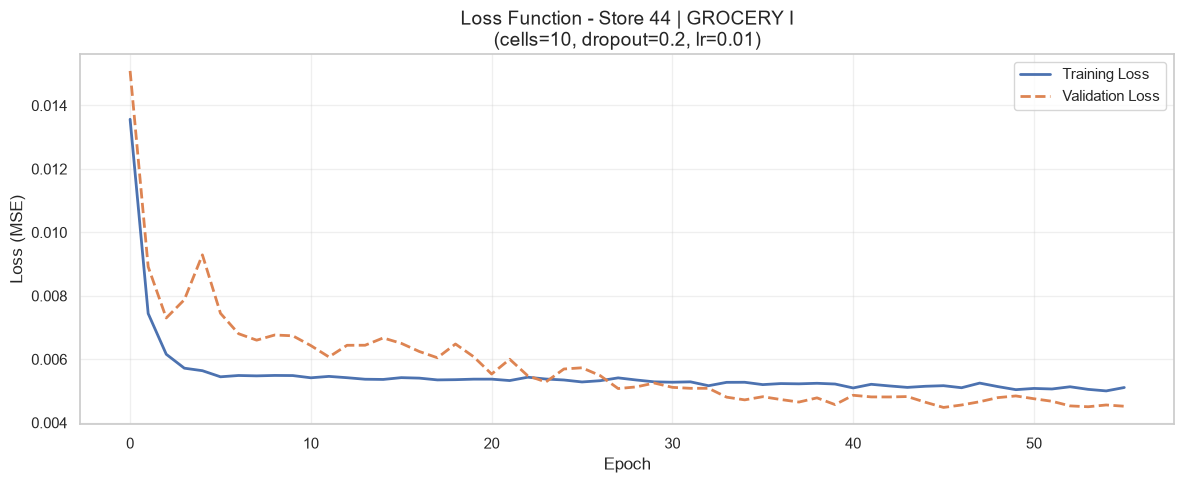


  Evaluasi pada Test Set:
  [LSTM - GROCERY I] MAE  = 2471.4422
  [LSTM - GROCERY I] RMSLE = 0.764361


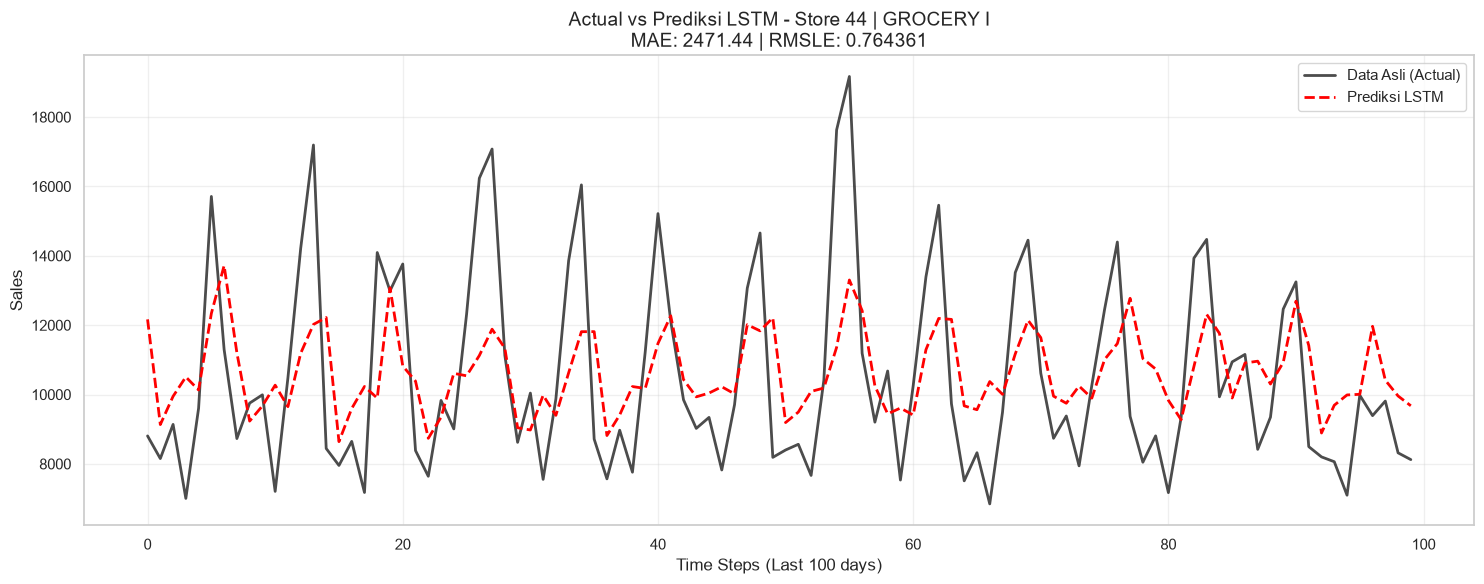


  HASIL LSTM TERBAIK: STORE 44 | FAMILY LAWN AND GARDEN
  Parameter Terbaik: cells=30, dropout=0.1, lr=0.01


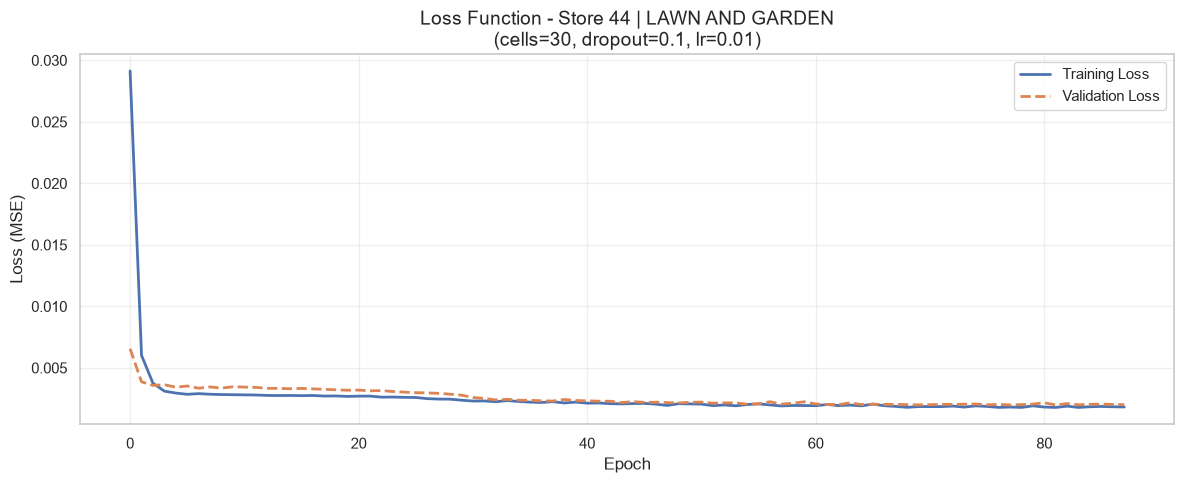


  Evaluasi pada Test Set:
  [LSTM - LAWN AND GARDEN] MAE  = 12.9530
  [LSTM - LAWN AND GARDEN] RMSLE = 0.732046


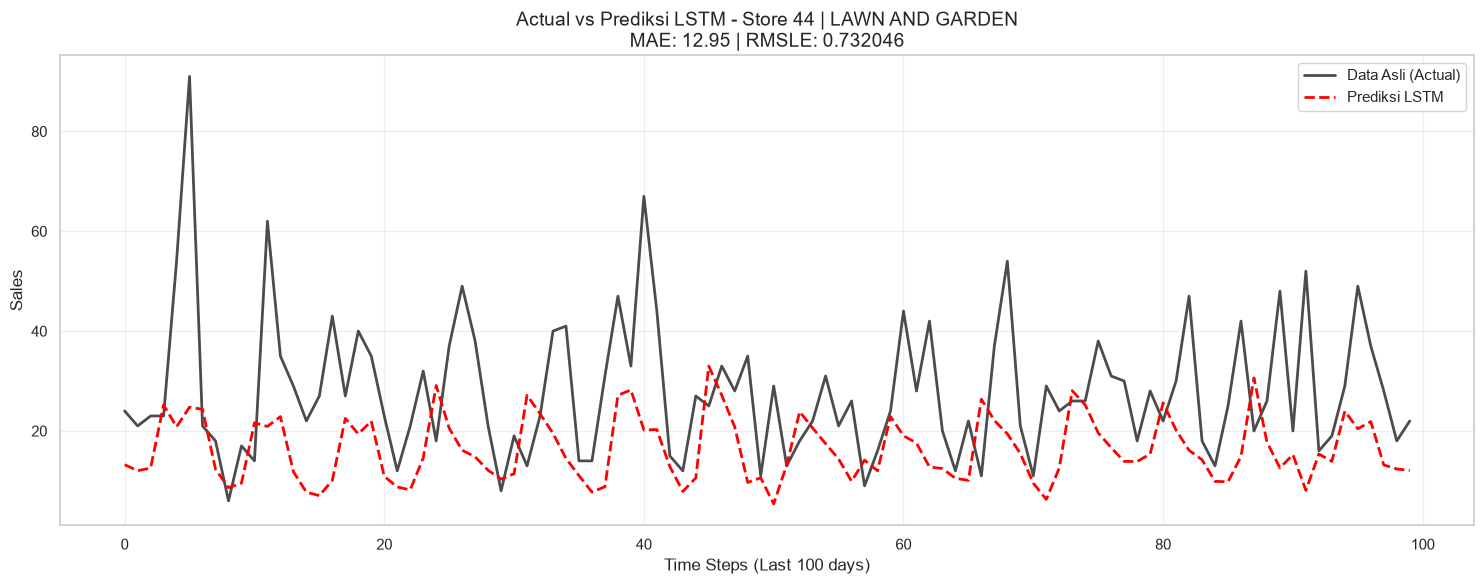


  HASIL LSTM TERBAIK: STORE 44 | FAMILY HARDWARE
  Parameter Terbaik: cells=50, dropout=0, lr=0.01


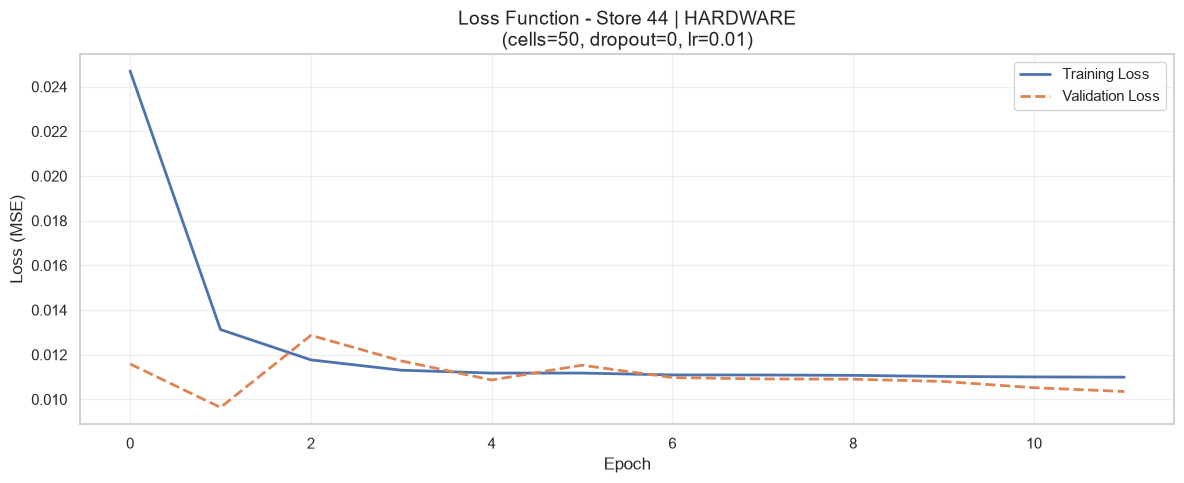


  Evaluasi pada Test Set:
  [LSTM - HARDWARE] MAE  = 2.1468
  [LSTM - HARDWARE] RMSLE = 0.606864


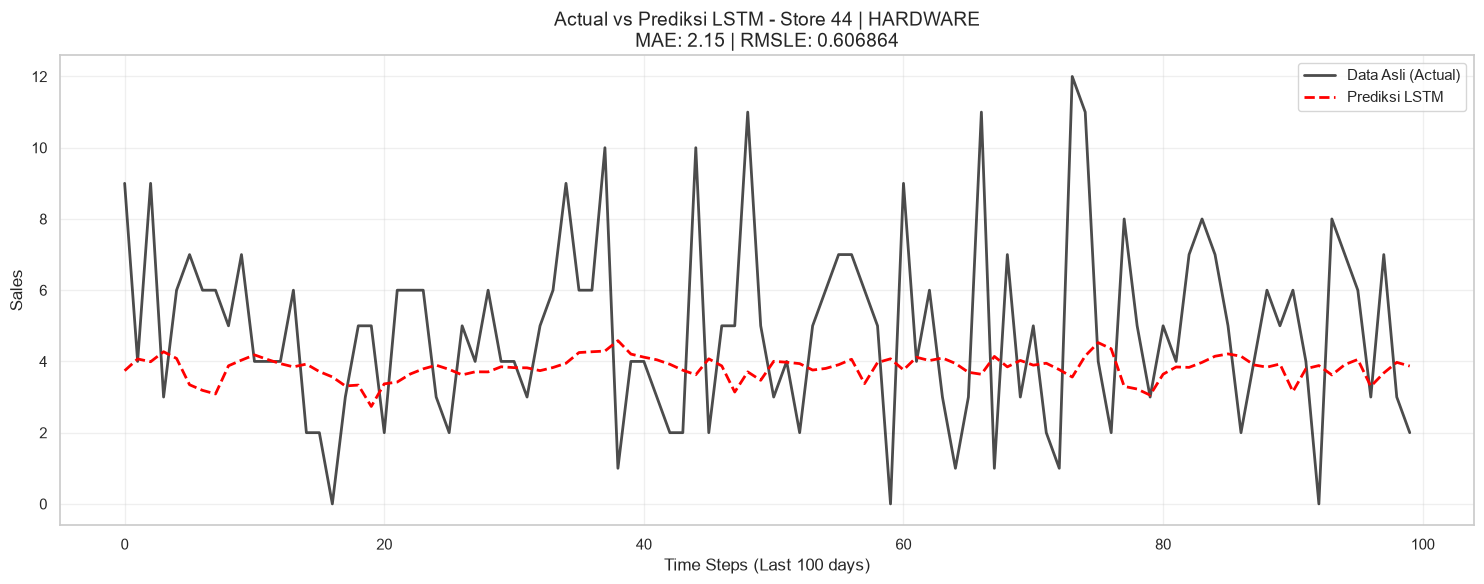


Selesai menampilkan hasil untuk semua 3 skenario.


In [45]:
# =============================================================
# Plot Loss, Evaluasi, dan Plot Actual vs Prediksi untuk Setiap Skenario
# =============================================================

lstm_eval_results = []

for (store, family), data in processed_data.items():
    print(f"\n{'='*70}")
    print(f"  HASIL LSTM TERBAIK: STORE {store} | FAMILY {family}")
    print(f"{'='*70}")

    tuning = all_tuning_results[(store, family)]
    best_model = tuning['best_model']
    best_history = tuning['best_history']
    best_params = tuning['best_params']

    print(f"  Parameter Terbaik: cells={best_params[0]}, dropout={best_params[1]}, lr={best_params[2]}")

    # --- 1. Plot Loss Function ---
    plot_loss_history(
        best_history,
        title=f'Loss Function - Store {store} | {family}\n'
              f'(cells={best_params[0]}, dropout={best_params[1]}, lr={best_params[2]})'
    )

    # --- 2. Evaluasi pada Test Set (MAE & RMSLE) ---
    X_test = data['X_test_3d']
    y_test_actual = data['y_test_actual']
    scaler_y = data['scaler_y']

    preds_scaled = best_model.predict(X_test, verbose=0)
    preds = scaler_y.inverse_transform(preds_scaled).flatten()
    preds = np.maximum(preds, 0)  # Pastikan tidak ada prediksi negatif

    print(f"\n  Evaluasi pada Test Set:")
    mae, rmsle = evaluate_and_print(y_test_actual, preds, label=f'LSTM - {family}')

    lstm_eval_results.append({
        'Store': store,
        'Family': family,
        'Model': 'LSTM Tuned',
        'MAE': mae,
        'RMSLE': rmsle,
        'Best Cells': best_params[0],
        'Best Dropout': best_params[1],
        'Best LR': best_params[2]
    })

    # --- 3. Plot Actual vs Predicted ---
    plot_actual_vs_predicted(
        y_test_actual, preds,
        title=f'Actual vs Prediksi LSTM - Store {store} | {family}\n'
              f'MAE: {mae:.2f} | RMSLE: {rmsle:.6f}',
        last_n=100
    )

print(f"\nSelesai menampilkan hasil untuk semua {len(processed_data)} skenario.")

In [46]:
# =============================================================
# Tabel Evaluasi LSTM Tuned untuk Semua Skenario
# =============================================================

df_lstm_eval = pd.DataFrame(lstm_eval_results)

print('=== Evaluasi Model LSTM Tuned (Test Set) ===')
display(df_lstm_eval.round(4))

# Gabungkan dengan hasil baseline jika tersedia
if 'all_results' in dir() or 'all_results' in globals():
    # Hapus entri LSTM Tuned lama dan tambahkan yang baru
    all_results_updated = [r for r in all_results if r.get('Model') != 'LSTM Tuned']
    for res in lstm_eval_results:
        all_results_updated.append({
            'Store': res['Store'],
            'Family': res['Family'],
            'Model': 'LSTM Tuned',
            'MAE': res['MAE'],
            'RMSLE': res['RMSLE']
        })
    
    print('\n=== Perbandingan Semua Model (Baseline + LSTM Tuned) ===')
    df_all = pd.DataFrame(all_results_updated)
    display(df_all.sort_values(by=['Family', 'MAE']).reset_index(drop=True).round(4))

=== Evaluasi Model LSTM Tuned (Test Set) ===


,Store,Family,Model,MAE,RMSLE,Best Cells,Best Dropout,Best LR
0,44,GROCERY I,LSTM Tuned,2471.4422,0.7644,10,0.2,0.01
1,44,LAWN AND GARDEN,LSTM Tuned,12.9530,0.7320,30,0.1,0.01
2,44,HARDWARE,LSTM Tuned,2.1468,0.6069,50,0.0,0.01



=== Perbandingan Semua Model (Baseline + LSTM Tuned) ===


,Store,Family,Model,MAE,RMSLE
0,44,GROCERY I,XGBoost,1731.9870,0.7443
1,44,GROCERY I,Seasonal Naive,1948.3373,0.7925
2,44,GROCERY I,RNN,2080.4360,0.7675
3,44,GROCERY I,LSTM Tuned,2471.4422,0.7644
4,44,HARDWARE,LSTM Tuned,2.1468,0.6069
5,44,HARDWARE,RNN,2.1477,0.6168
6,44,HARDWARE,XGBoost,2.2233,0.6269
7,44,HARDWARE,Seasonal Naive,2.5313,0.7213
8,44,LAWN AND GARDEN,Seasonal Naive,12.5433,0.7250
9,44,LAWN AND GARDEN,LSTM Tuned,12.9530,0.7320


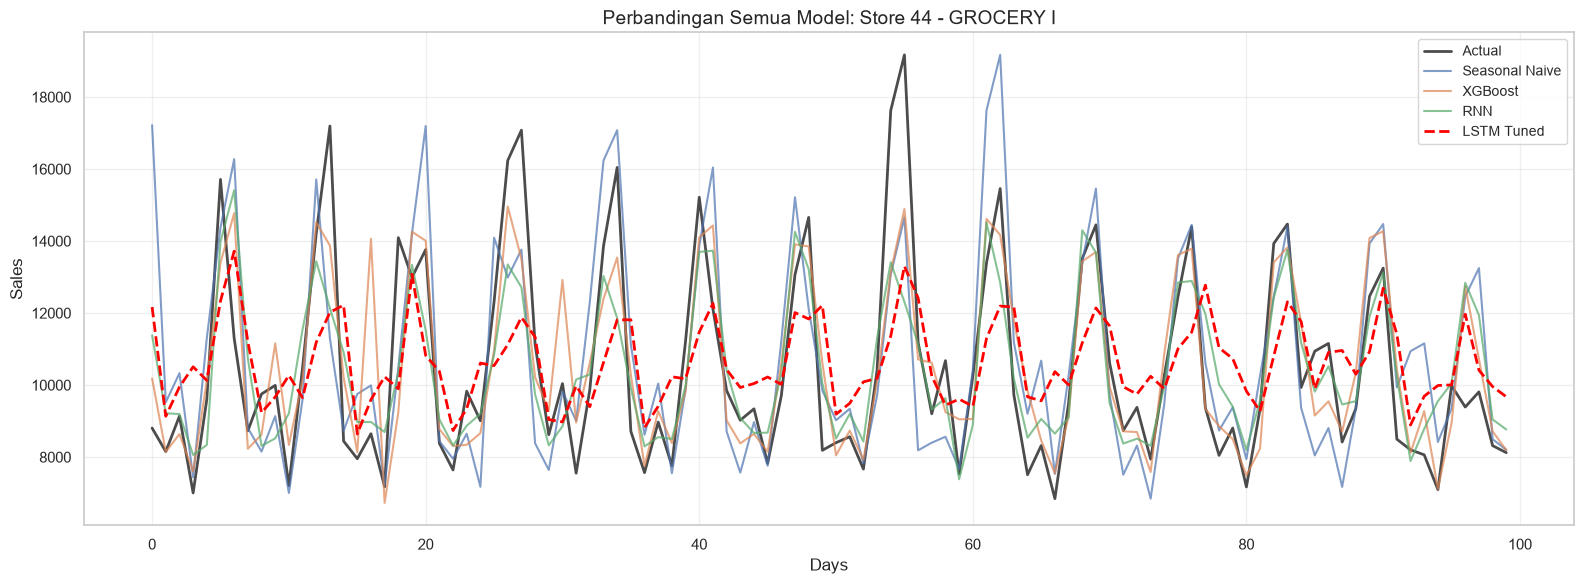

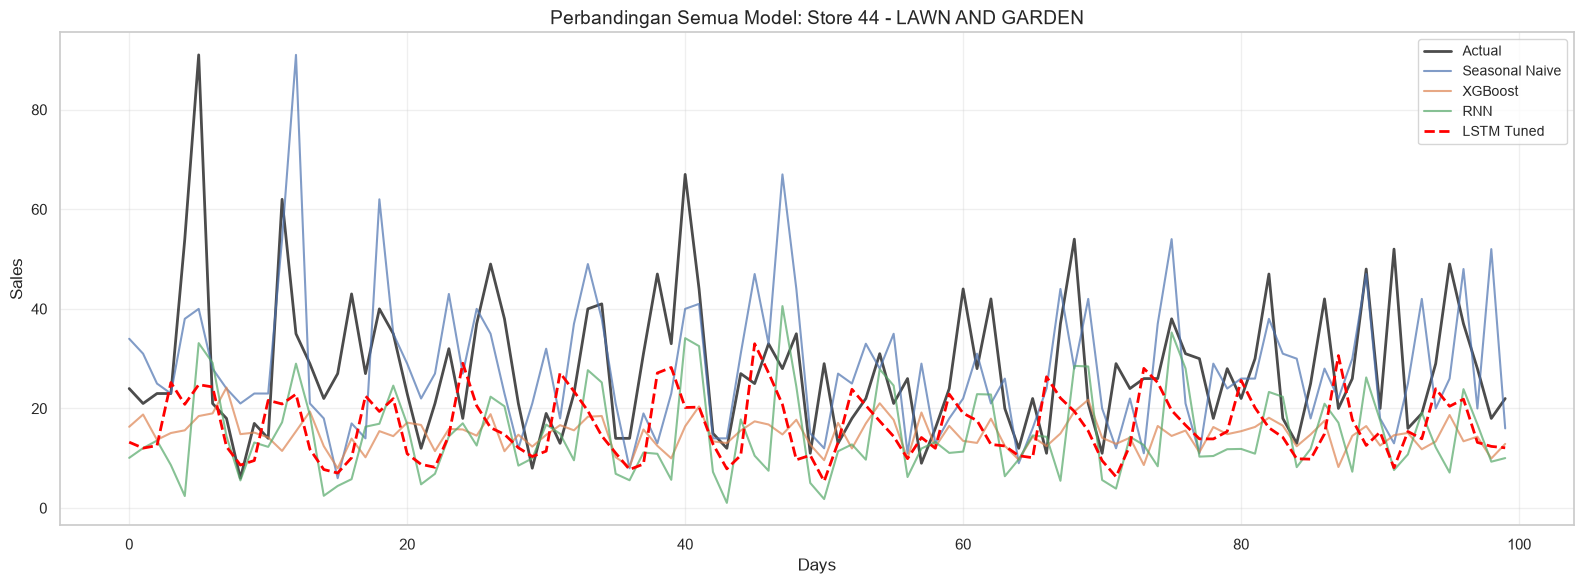

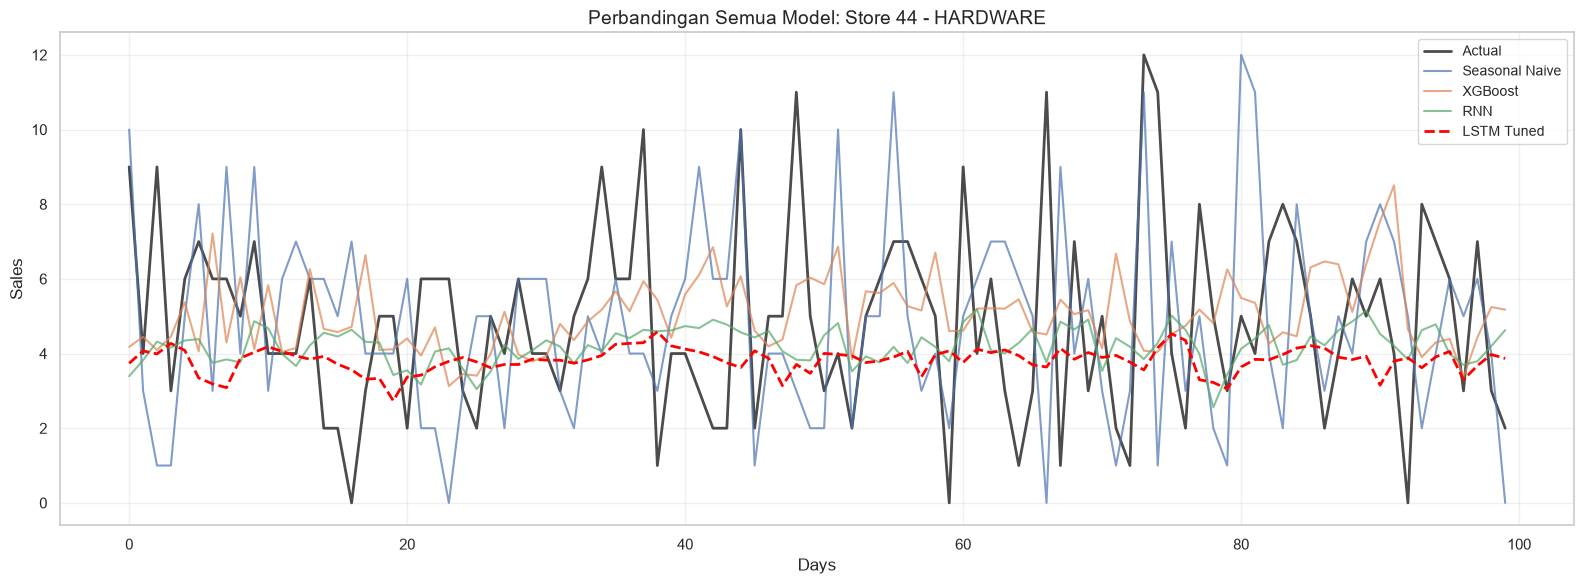

In [47]:
# =============================================================
# Plot Perbandingan Semua Model (Baseline + LSTM) per Skenario
# =============================================================

def plot_all_models_comparison(store, family, last_n=150):
    """
    Memplot perbandingan prediksi semua model (Seasonal Naive, XGBoost, RNN, LSTM Tuned)
    terhadap data aktual pada skala asli.
    """
    if (store, family) not in processed_data:
        print(f"Data untuk {store} - {family} tidak ditemukan.")
        return

    data = processed_data[(store, family)]
    scaler_y = data['scaler_y']
    X_test_3d = data['X_test_3d']
    y_test_actual = data['y_test_actual']

    # 1. Seasonal Naive
    snaive_p_scaled = X_test_3d[:, (TIME_STEPS - 7), 0]
    snaive_p = np.maximum(scaler_y.inverse_transform(snaive_p_scaled.reshape(-1, 1)).flatten(), 0)

    # 2. XGBoost
    xgb_m = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED)
    xgb_m.fit(data['X_train_3d'].reshape(data['X_train_3d'].shape[0], -1), data['y_train_scaled'])
    xgb_p_scaled = xgb_m.predict(X_test_3d.reshape(X_test_3d.shape[0], -1))
    xgb_p = np.maximum(scaler_y.inverse_transform(xgb_p_scaled.reshape(-1, 1)).flatten(), 0)

    # 3. RNN
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    rnn_m = Sequential([
        Input(shape=(TIME_STEPS, X_test_3d.shape[2])),
        SimpleRNN(64, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32),
        Dense(1)
    ])
    rnn_m.compile(optimizer='adam', loss='mse')
    rnn_m.fit(data['X_train_3d'], data['y_train_scaled'], epochs=10, batch_size=32, verbose=0)
    rnn_p_scaled = rnn_m.predict(X_test_3d, verbose=0)
    rnn_p = np.maximum(scaler_y.inverse_transform(rnn_p_scaled).flatten(), 0)

    # 4. LSTM Tuned
    best_lstm = all_tuning_results[(store, family)]['best_model']
    lstm_p_scaled = best_lstm.predict(X_test_3d, verbose=0)
    lstm_p = np.maximum(scaler_y.inverse_transform(lstm_p_scaled).flatten(), 0)

    # Evaluasi semua model
    mae_sn, rmsle_sn = evaluate_metrics(y_test_actual, snaive_p)
    mae_xgb, rmsle_xgb = evaluate_metrics(y_test_actual, xgb_p)
    mae_rnn, rmsle_rnn = evaluate_metrics(y_test_actual, rnn_p)
    mae_lstm, rmsle_lstm = evaluate_metrics(y_test_actual, lstm_p)

    # Visualisasi
    plt.figure(figsize=(16, 6))
    plt.plot(y_test_actual[-last_n:], label='Actual', color='black', linewidth=2, alpha=0.7)
    plt.plot(snaive_p[-last_n:], label=f'Seasonal Naive', alpha=0.7)
    plt.plot(xgb_p[-last_n:], label=f'XGBoost', alpha=0.7)
    plt.plot(rnn_p[-last_n:], label=f'RNN', alpha=0.7)
    plt.plot(lstm_p[-last_n:], label=f'LSTM Tuned', color='red', linewidth=2, linestyle='--')

    plt.title(f'Perbandingan Semua Model: Store {store} - {family}', fontsize=14)
    plt.xlabel('Days', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Plot perbandingan untuk semua skenario
for fam in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    plot_all_models_comparison(44, fam, last_n=100)

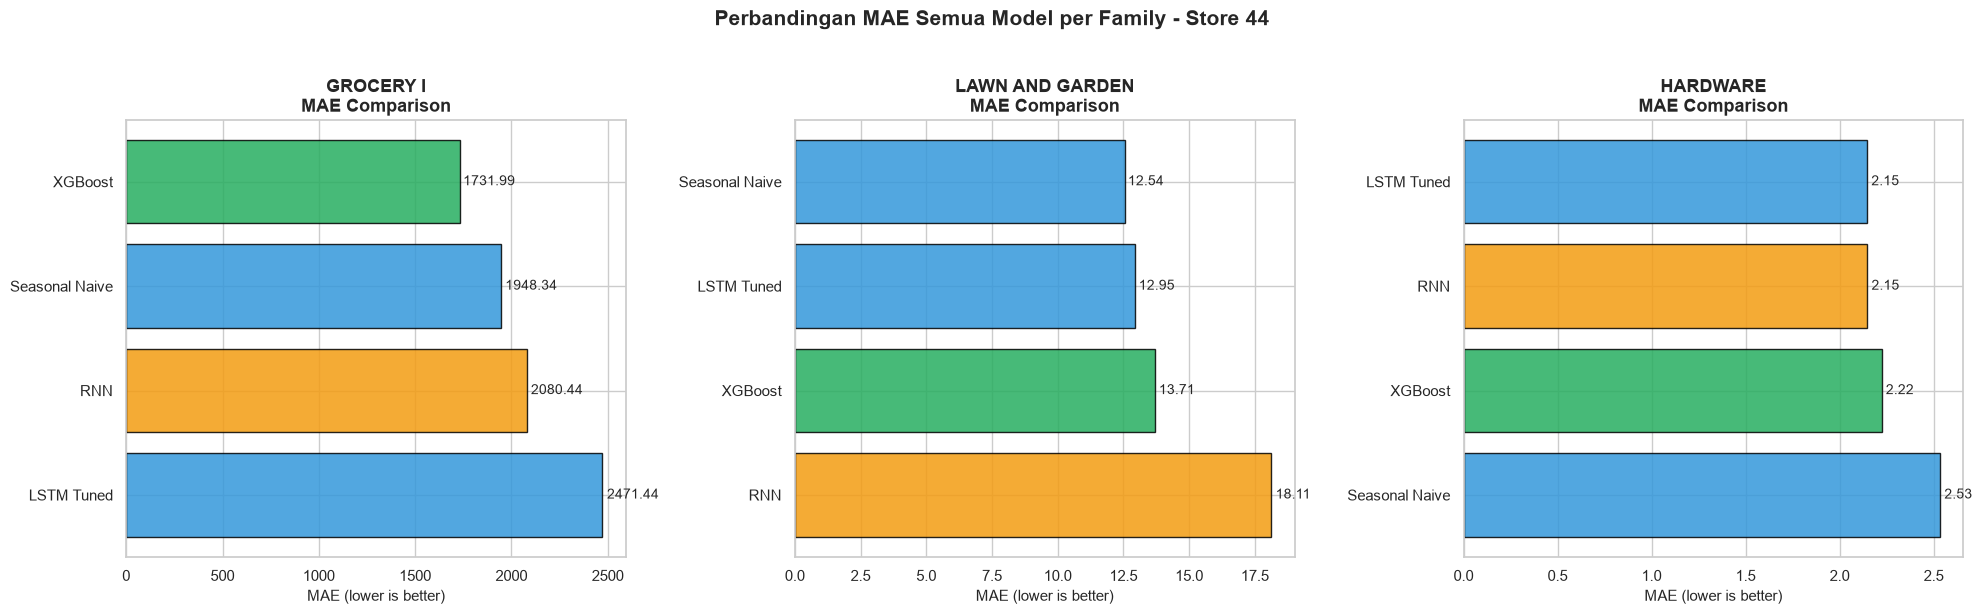

In [48]:
# =============================================================
# Bar Chart Perbandingan MAE & RMSLE per Family
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, family in enumerate(['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']):
    df_fam = df_all[df_all['Family'] == family].sort_values('MAE')

    colors_bar = []
    for m in df_fam['Model']:
        if m == 'LSTM Improved':
            colors_bar.append('#e74c3c')  # Red for LSTM
        elif m == 'RNN':
            colors_bar.append('#f39c12')  # Orange for RNN
        elif m == 'XGBoost':
            colors_bar.append('#27ae60')  # Green for XGBoost
        else:
            colors_bar.append('#3498db')  # Blue for Seasonal Naive

    axes[idx].barh(df_fam['Model'], df_fam['MAE'], color=colors_bar, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'{family}\nMAE Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('MAE (lower is better)', fontsize=11)
    axes[idx].invert_yaxis()

    # Annotate values
    for i, (mae_val, model) in enumerate(zip(df_fam['MAE'], df_fam['Model'])):
        axes[idx].text(mae_val * 1.01, i, f'{mae_val:.2f}', va='center', fontsize=10)

plt.suptitle('Perbandingan MAE Semua Model per Family - Store 44', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

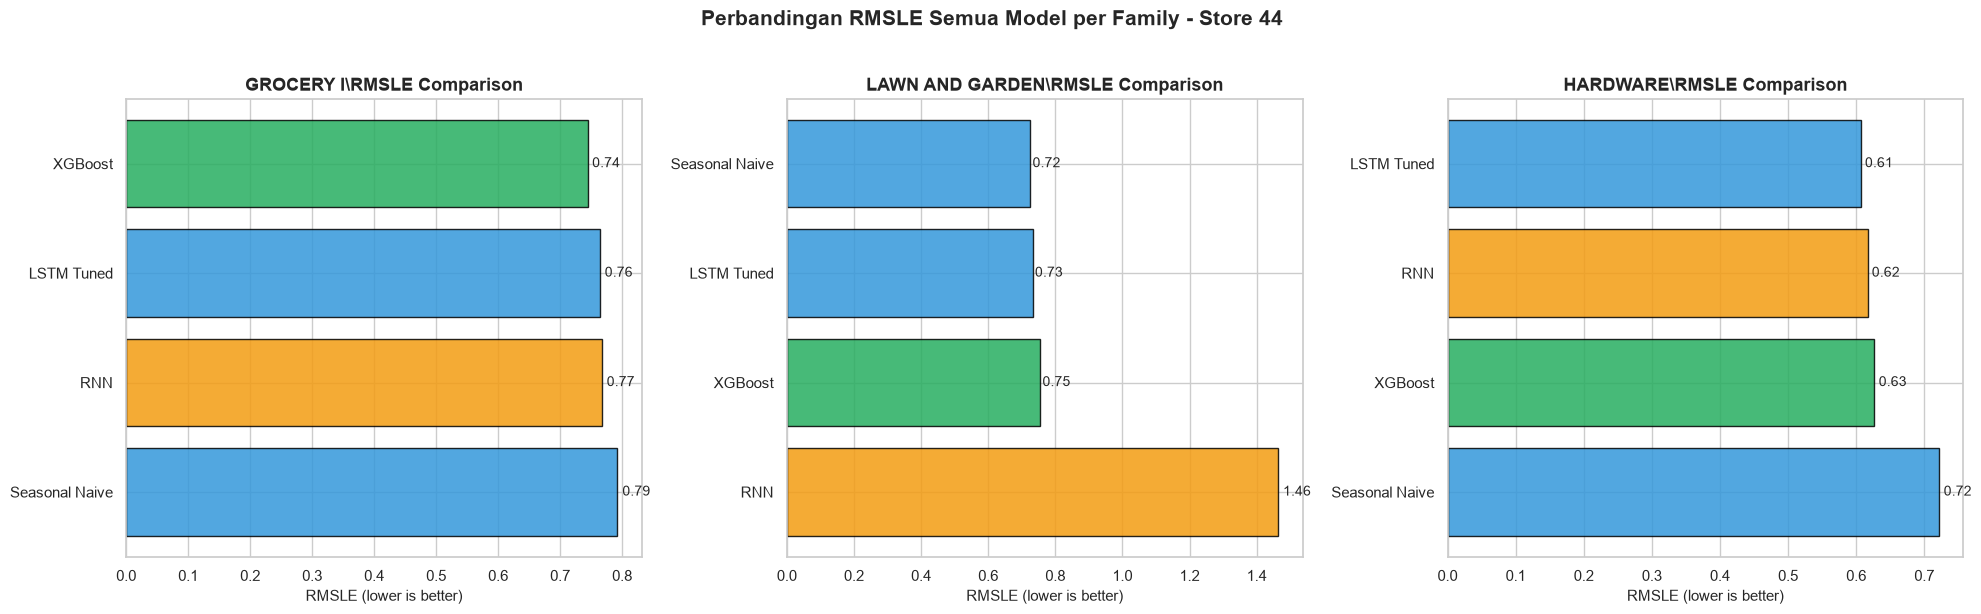

In [49]:
# =============================================================
# Bar Chart Perbandingan MAE & RMSLE per Family
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, family in enumerate(['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']):
    df_fam = df_all[df_all['Family'] == family].sort_values('RMSLE')

    colors_bar = []
    for m in df_fam['Model']:
        if m == 'LSTM Improved':
            colors_bar.append('#e74c3c')  # Red for LSTM
        elif m == 'RNN':
            colors_bar.append('#f39c12')  # Orange for RNN
        elif m == 'XGBoost':
            colors_bar.append('#27ae60')  # Green for XGBoost
        else:
            colors_bar.append('#3498db')  # Blue for Seasonal Naive

    axes[idx].barh(df_fam['Model'], df_fam['RMSLE'], color=colors_bar, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'{family}\RMSLE Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('RMSLE (lower is better)', fontsize=11)
    axes[idx].invert_yaxis()

    # Annotate values
    for i, (mae_val, model) in enumerate(zip(df_fam['RMSLE'], df_fam['Model'])):
        axes[idx].text(mae_val * 1.01, i, f'{mae_val:.2f}', va='center', fontsize=10)

plt.suptitle('Perbandingan RMSLE Semua Model per Family - Store 44', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()